# **Employee Performance Analysis**

## Business Case : 

**The objective is to predict employee performance based on the available features in the dataset.**

INX Future Inc. is a leading data analytics and automation company with over 15 years of global presence and a strong reputation as a top employer.
Recently, the company has faced a decline in employee performance, leading to increased service issues.
Client satisfaction has also dropped by 8%, raising concerns for top management.
CEO Mr. Brain is aware of the problem but hesitant to take strict action.
Penalizing employees may negatively impact morale and harm the company’s employer brand.
To address this, a data science project has been initiated.
The goal is to analyze employee data and identify root causes of poor performance.
The project also aims to detect non-performing employees using a predictive model.
This will help in making fair and data-driven decisions.
Ultimately, the objective is to improve employee performance while maintaining company reputation and client satisfaction.

In [1]:
!pip install xgboost

In [2]:
!pip install pandas xlrd

### Importing the libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
data = pd.read_excel("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls")

In [5]:
data

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3


### Dataset Overview

Total Records : 1200

Total Features : 28

Target variable : PerformanceRating

Type of problem : BMulti-class classification

### Columns Description

- **EmpNumber** shows uniqe ID number of each Employee and it is not required for modeling and analysing.
- **Age** shows how much the employee is older.
- **Gender** is the sex of employee (Male , Female , Transgender).
- **EducationBackground** is the specialization of employees in which they studied.
- **MaritalStatus** shows that the employee is married or not (Married, Unmarried , Single).
- **EmpDepartment** is the department of employee in which they working.
- **EmpJobRole** shows the position of employee.
- **BusinessTravelFrequency** means how many times the employee travels for the field or near to clients.
- **DistanceFromHome** is how far the employee stays from the company.
- **EmpEducationLevel** is the highest qualification of employee.
- **EmpEnvironmentSatisfaction** is a rating about the work calture or Environment in which they works.
- **EmpHourlyRate** shows how much time employee works in a day.
- **EmpJobInvolvement** is the  employee's emotional investment in their work.
- **EmpJobLevel** is the employee's position within the organization.
- **EmpJobSatisfaction** is level of job satisfaction that employees experience in their current roles.
- **NumCompaniesWorked** shows that how many companies the employee worked before.
- **OverTime** indicating whether an employee works beyond their regular hours.
- **EmpLastSalaryHikePercent**  percentage increase in an employee's salary during their most recent salary hike.
- **EmpRelationshipSatisfaction** shows that the relationships with colleagues, supervisors, and team members.
- **TotalWorkExperienceInYears** is the number of years of work experience that an employee has accumulated throughout their career.
- **TrainingTimesLastYear** is the number of times an employee received training in the last year.
- **EmpWorkLifeBalance**shows that how well an employee can manage their professional and personal commitments.
- **ExperienceYearsAtThisCompany** indicates the number of years an employee has worked at their current company.
- **ExperienceYearsInCurrentRole** represent the number of years an employee has spent in their current job role or position within the organization.
- **YearsSinceLastPromotion** indicates the number of years that have elapsed since an employee's last promotion within the organization.
- **YearsWithCurrManager** shows that the number of years an employee has worked under their current manager.
- **Attrition** used to determine whether an employee has left the organization or is still employed
- **PerformanceRating** represent an employee's performance rating within the organization and it is our Target Class.based on it we predict about employee.

### Basic Checks

In [6]:
pd.set_option('display.max_columns',None)
data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


### Insights from " data.describe() " :

- **Age** Average age of the employees is 36.9 with a range from 18 years to 60 years.
- **DistanceFromHome** Average distance from home to the workplace is about 9.17 km with a range from 1 km to 29 km.

- **EmpHourlyRate** Average hourly rate is around 65.98K, with a range from 30K to 100K.
- **NumCompaniesWorked** 75% employees worked on 4 companies.
- **EmpLastSalaryHikePercent** Average last salary hike percentage is approximately 15.22% with a maximum hike of 25%.
- **TotalWorkExperienceInYears** 75% of employees having 15 year of experience with maximum of 40 year work experience.
- **TrainingTimesLastYear** 75% Employees had 3 training times last year.
- **ExperienceYearsAtThisCompany** Average years in the current role is approximately 4.29 years.
- **ExperienceYearsInCurrentRole** Employees having average 3.6 years of experiance in current role.
- **YearsSinceLastPromotion** 75% employees are not promoted from past 3 years.
- **YearsWithCurrManager** 75% employees are working with the current manager since 7 years.

In [10]:
data.describe(include="O")

,EmpNumber,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,OverTime,Attrition
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,2,6,3,6,19,3,2,2
top,E100967,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Rarely,No,No
freq,1,725,492,548,373,270,846,847,1022


### Insights from " data.describe(include="O") " :

- Dataset having two genders with 725 Males and remaining Females.
- Employees have 6 types of educational background in which Life Science is most occured.
- MaritalStatus has 3 types but 548 employees married.
- Six types of Employee Departments but Sales has highest counts.
- 270 employees are working as Sales Executive but 19 different types of Job role are there.
- Business travel frequency is categorized into three levels, with "Travel_Rarely" being the most common (846 occurrences).
- Most employees do not work overtime.
- The majority of employees in the dataset do not have attrition records, with "No" being the most frequent value (1022 occurrences).

In [11]:
print('UNIQUE VALUES: \n')
for i in data.columns:
    print(i,':', data[i].unique())

UNIQUE VALUES: 

EmpNumber : ['E1001000' 'E1001006' 'E1001007' ... 'E100994' 'E100995' 'E100998']
Age : [32 47 40 41 60 27 50 28 36 38 44 30 29 42 34 39 56 53 35 52 33 25 45 23
 26 54 37 24 49 55 43 51 22 31 58 20 21 48 19 18 59 46 57]
Gender : ['Male' 'Female']
EducationBackground : ['Marketing' 'Life Sciences' 'Human Resources' 'Medical' 'Other'
 'Technical Degree']
MaritalStatus : ['Single' 'Married' 'Divorced']
EmpDepartment : ['Sales' 'Human Resources' 'Development' 'Data Science'
 'Research & Development' 'Finance']
EmpJobRole : ['Sales Executive' 'Manager' 'Developer' 'Sales Representative'
 'Human Resources' 'Senior Developer' 'Data Scientist'
 'Senior Manager R&D' 'Laboratory Technician' 'Manufacturing Director'
 'Research Scientist' 'Healthcare Representative' 'Research Director'
 'Manager R&D' 'Finance Manager' 'Technical Architect' 'Business Analyst'
 'Technical Lead' 'Delivery Manager']
BusinessTravelFrequency : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
DistanceFr

### Exploratory Data Analysis(EDA)

In [12]:
data.drop('EmpNumber',axis=1,inplace=True)

In [13]:
# Violin plot

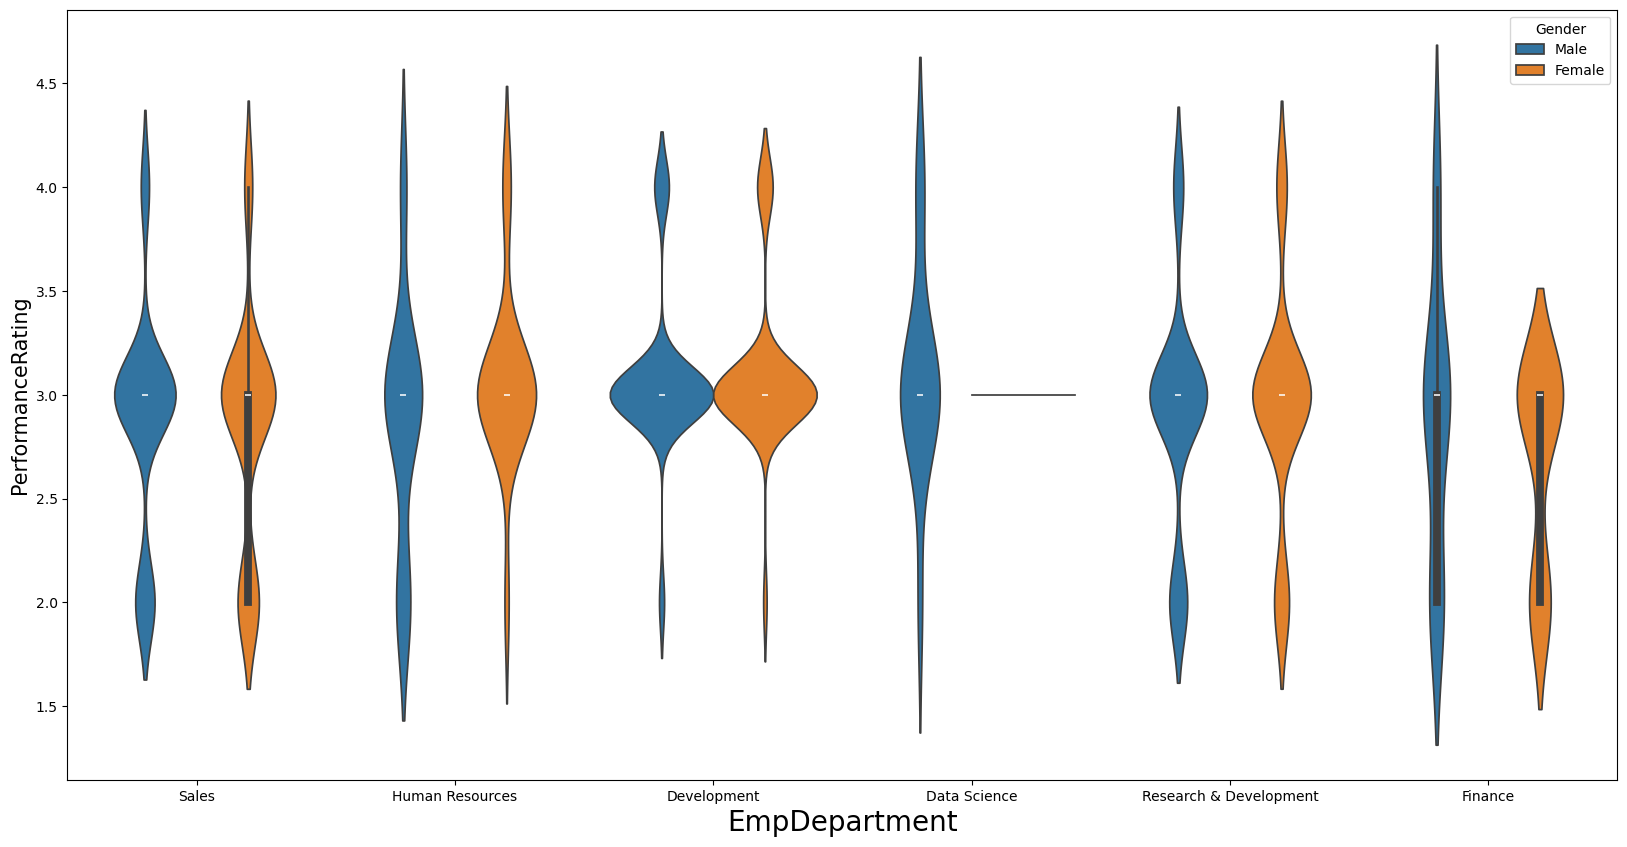

In [14]:
plt.figure(figsize=(20,10),facecolor='white')
sns.violinplot(x='EmpDepartment',y='PerformanceRating',hue=data.Gender,data=data)
plt.xlabel('EmpDepartment',fontsize=20)
plt.ylabel('PerformanceRating',fontsize=15)
plt.show()

**Violinplot:**  It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared.
  
Overall, employee performance across all departments is centered around a rating of 3, indicating average performance. Departments like Development and Data Science show more consistent and stable performance, while Sales, HR, and Finance exhibit greater variability with both low and high performers. Research & Development shows moderate variation but remains mostly balanced. There is no significant difference between male and female performance across departments.

### Univariate Data Analysis

In [15]:
num_data = data[['Age','DistanceFromHome','EmpHourlyRate','NumCompaniesWorked','EmpLastSalaryHikePercent',
               'TotalWorkExperienceInYears','TrainingTimesLastYear','ExperienceYearsAtThisCompany',
                    'ExperienceYearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']]

cat_data = data.drop(num_data,axis=1)

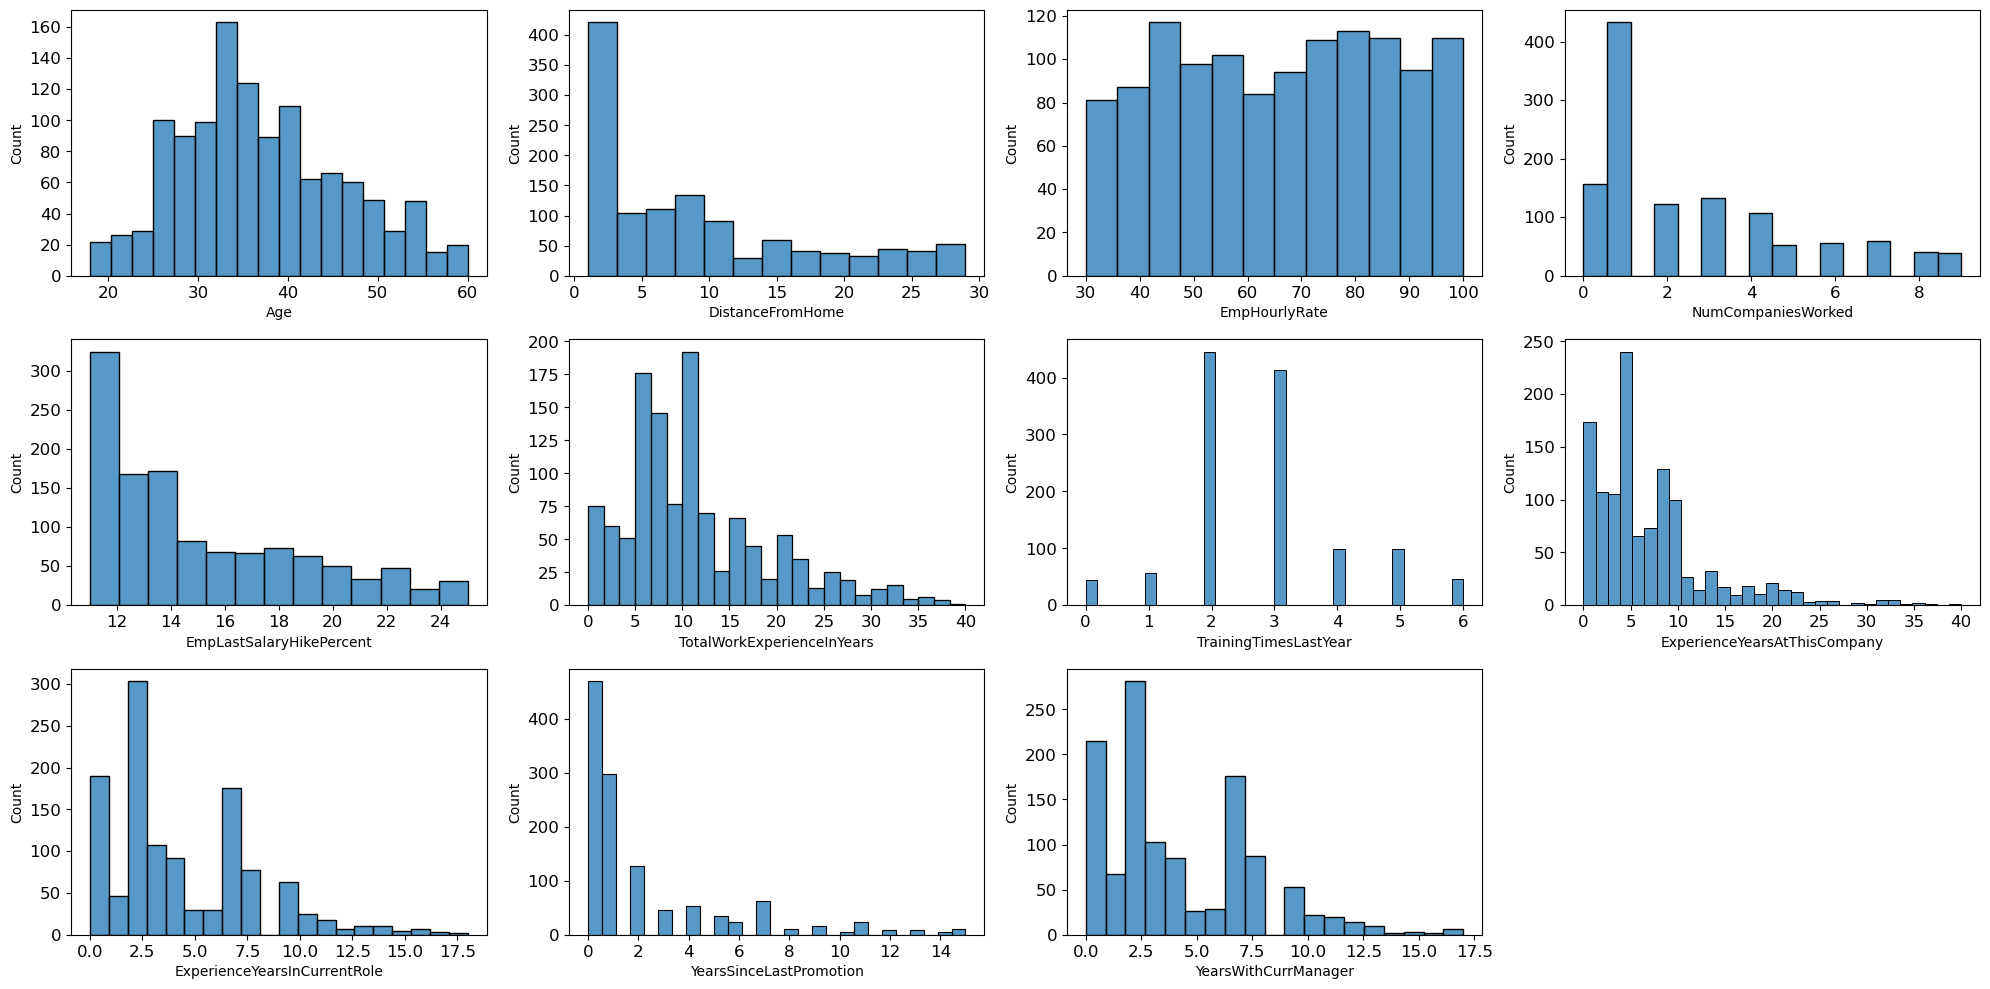

In [16]:
# Univariate Analysis for Numerical Data

plt.figure(figsize=(20,10))                
plotnumber = 1
for i in num_data.columns :           
    plt.subplot(3,4,plotnumber)           
    sns.histplot(x = data[i])             
    plt.xticks(fontsize=12)               
    plt.yticks(fontsize=12)               
    plotnumber = plotnumber + 1
plt.tight_layout() 

### Insights from Numerical Univariate Analysis :

- The majority of employees working at INX are in the age group of 25 to 40.
- Approximately 35% of employees reside within a 3 km range from the office,while 30% of employees live more than 10 km away from the office.
- All employees charging between 80 - 120 per hour.
- 13% employee are not worked for any company i.e they are freshers and 36% employee worked for only 1 company , so they are also freshers.
- 61% employee having only 11 - 15 % of salary hike from last salary.
- 70% employee get trained for 2 or 3 times in last year.
- 35% employee having upto 5 year of experience while 40% having 10 - 15 year of experience.
- only 10 % employees having more than 20 years of experiance, so they are loyal to the company and working hard.
- only 60% employees having upto 5 year of working experience in Current role.
- only 5% employee are not promoted from more than 10 years but upto 80% employee promoted within 2 years.
- 40% employee worked from last 2 year under the current manager.

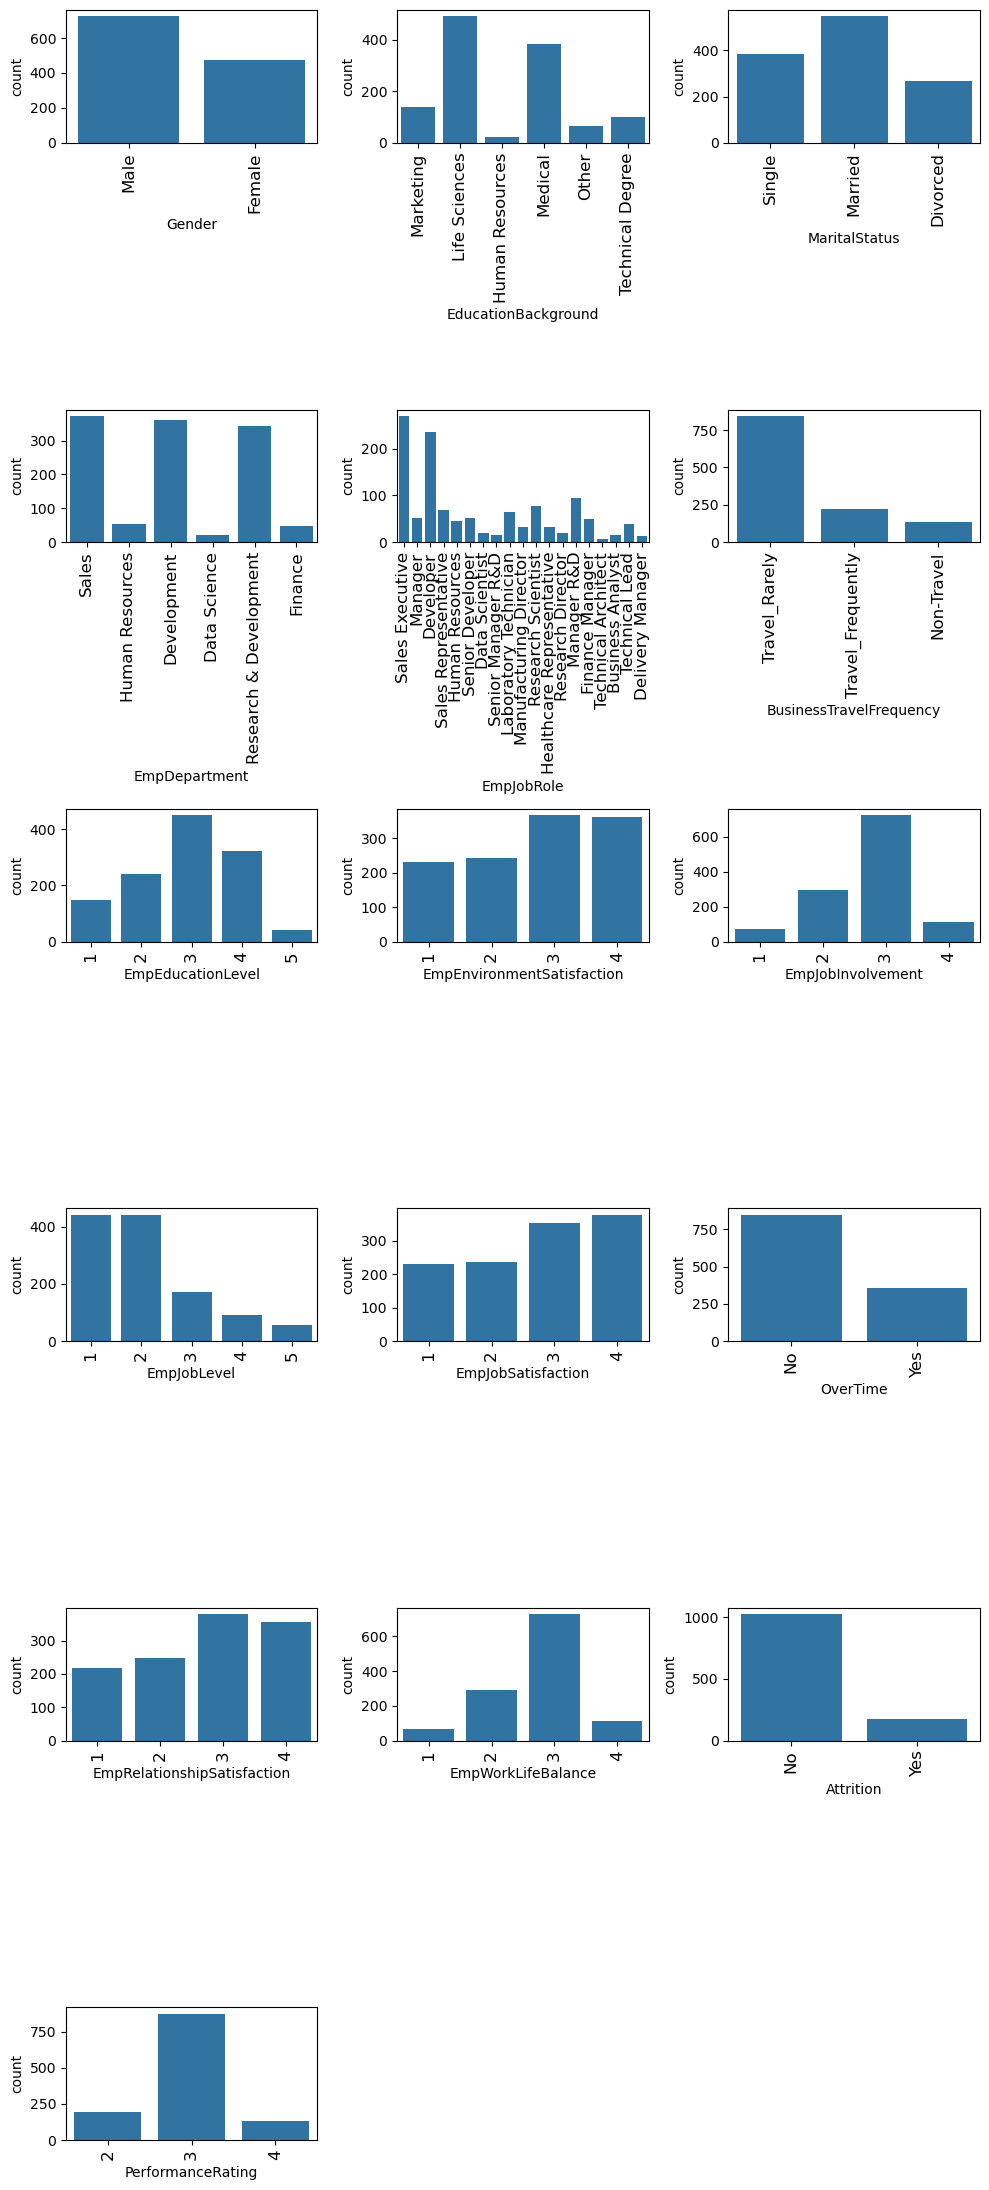

In [17]:
# Univariate Analysis for Categorical Data

plt.figure(figsize=(10,22))                                   
plotnumber = 1
for i in cat_data.columns :                                     
    plt.subplot(6,3,plotnumber)                                
    sns.countplot(x = data[i])                                  
    plt.xticks(rotation = 90,fontsize=12)                      
    plotnumber = plotnumber + 1
plt.tight_layout()  

### Insights from categorical univariate Analysis :

- In Gender there are 60% male & 40% female Employees.
- 41% employees having Life Science background, followed by medical background which is 32%.
- 46% employee are merried , 32% single and 22% employee are divorsed.
- 31% employee in sales , 30% in Developement , 29% in research department.
- 22% employee works in Sales executive and 20% in developement role.
- 70% employee travels rarely and 18% travels frequently but 12 % are not travelled.
- 37% employee have lavel 3 , 27% have lavel 4 educational level.
- more than 60% employee having good environment Satisfaction rating of 3 or 4 out of 5 star.
- 60 % employee moderately involved in their job while only 9 % highly involved.
- Approximately 75% employee having 1 or 2 job level.
- 40% employee have not satisfied in their job while 60% employee satisfied.
- only 30% employee prefered for over time, remaining are not.
- 40% employee have not satisfied relationship with their collegue or senior.
- only 10% employee managed well their work life while 30% employee are not and 60% employee moderately balanced their work life.
- 85% employee are not dragged in job 15% are dragged or having attrition in job.
- only 11% employee performs well in their work and 73% are moderate but 16% employee are not performed well.

### Bivariate Data Analysis

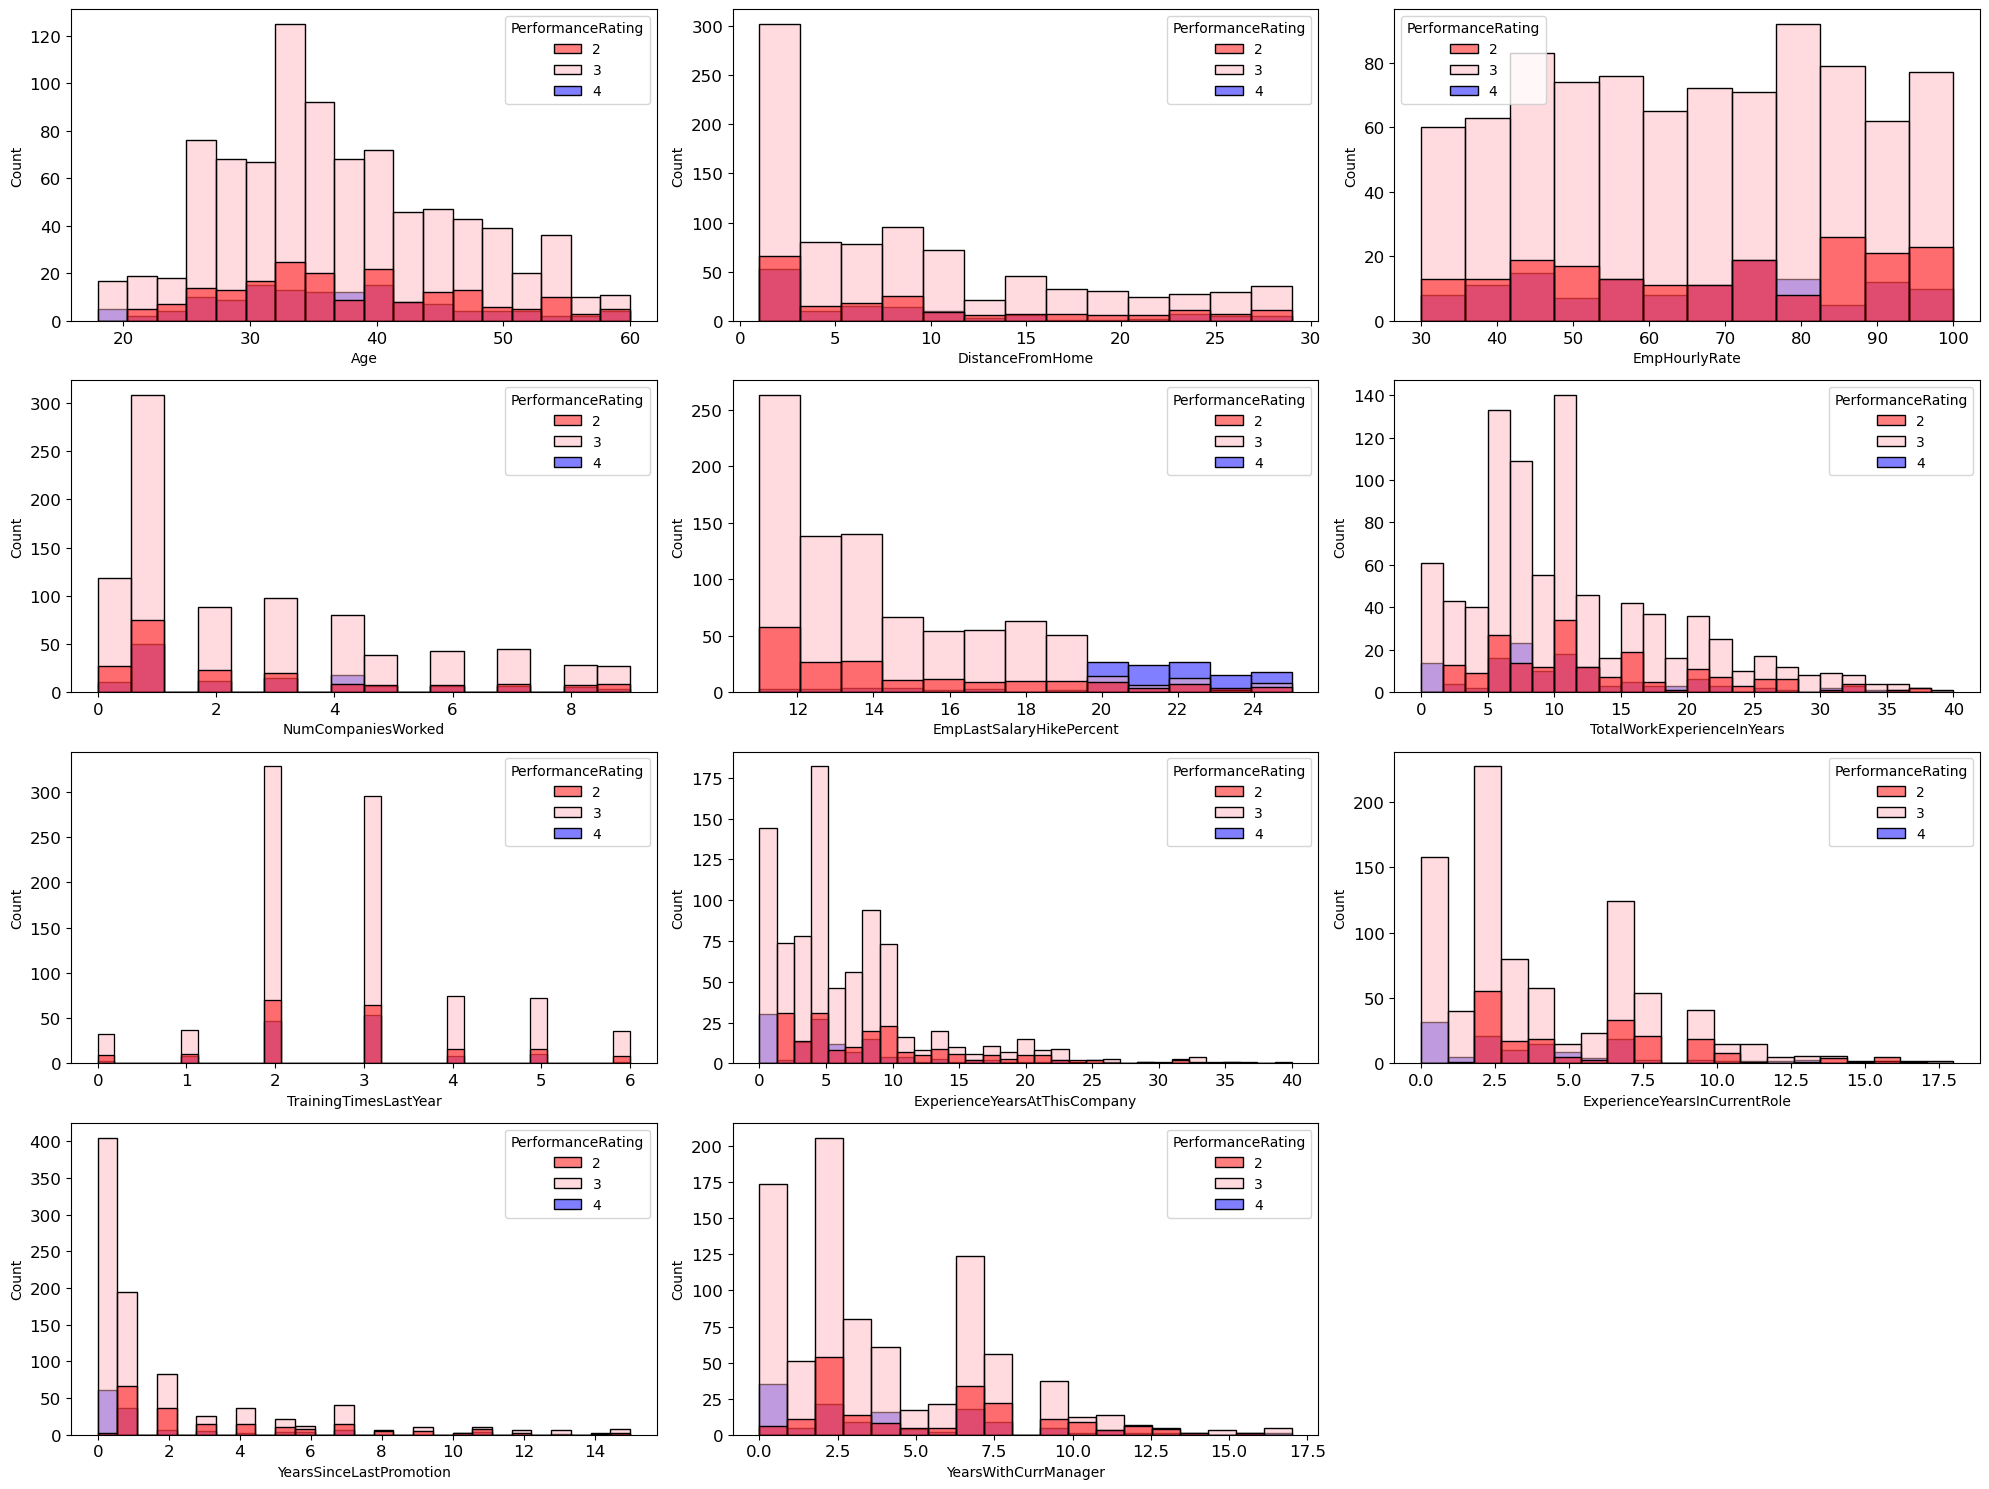

In [18]:
# Bivariate Analysis of Numerical Data
plt.figure(figsize=(20,15))         
plotnumber = 1                     
for i in num_data.columns :        
    plt.subplot(4,3,plotnumber)    
    sns.histplot(x = data[i],hue = data.PerformanceRating,palette=["red","lightpink","blue"])
    plt.xticks(fontsize=12)         
    plt.yticks(fontsize=12)         
    plotnumber = plotnumber + 1     
plt.tight_layout()    

### Insights From Bivariate Analysis of Numerical Data :

- Employee whose age between 25 - 45 their performance seems to bad.
- whose distance of office from home is less then 10 km , their performance is Bad.
- whose Hourly rate is more than 85 , their performance is also bad.
- who worked for only one company their performance seems bad.
- whose salary hike is below 14% their performance is too low but whose hike is grater than 20 , their performance is very good.
- whose experience is between 5 - 15 years , their performance seems bad.
- whose training time is 2 or 3 times , their performance is bad.
- who are fresher or worked for 10 year in this company , their performance is bad.
- who worked for 2 year in same role , his performance is bad.
- employee who promoted with in 4 year , his performance is bad.
- employee who worked 2 year or more than 6.5 year under the current manager his performance is also bad.

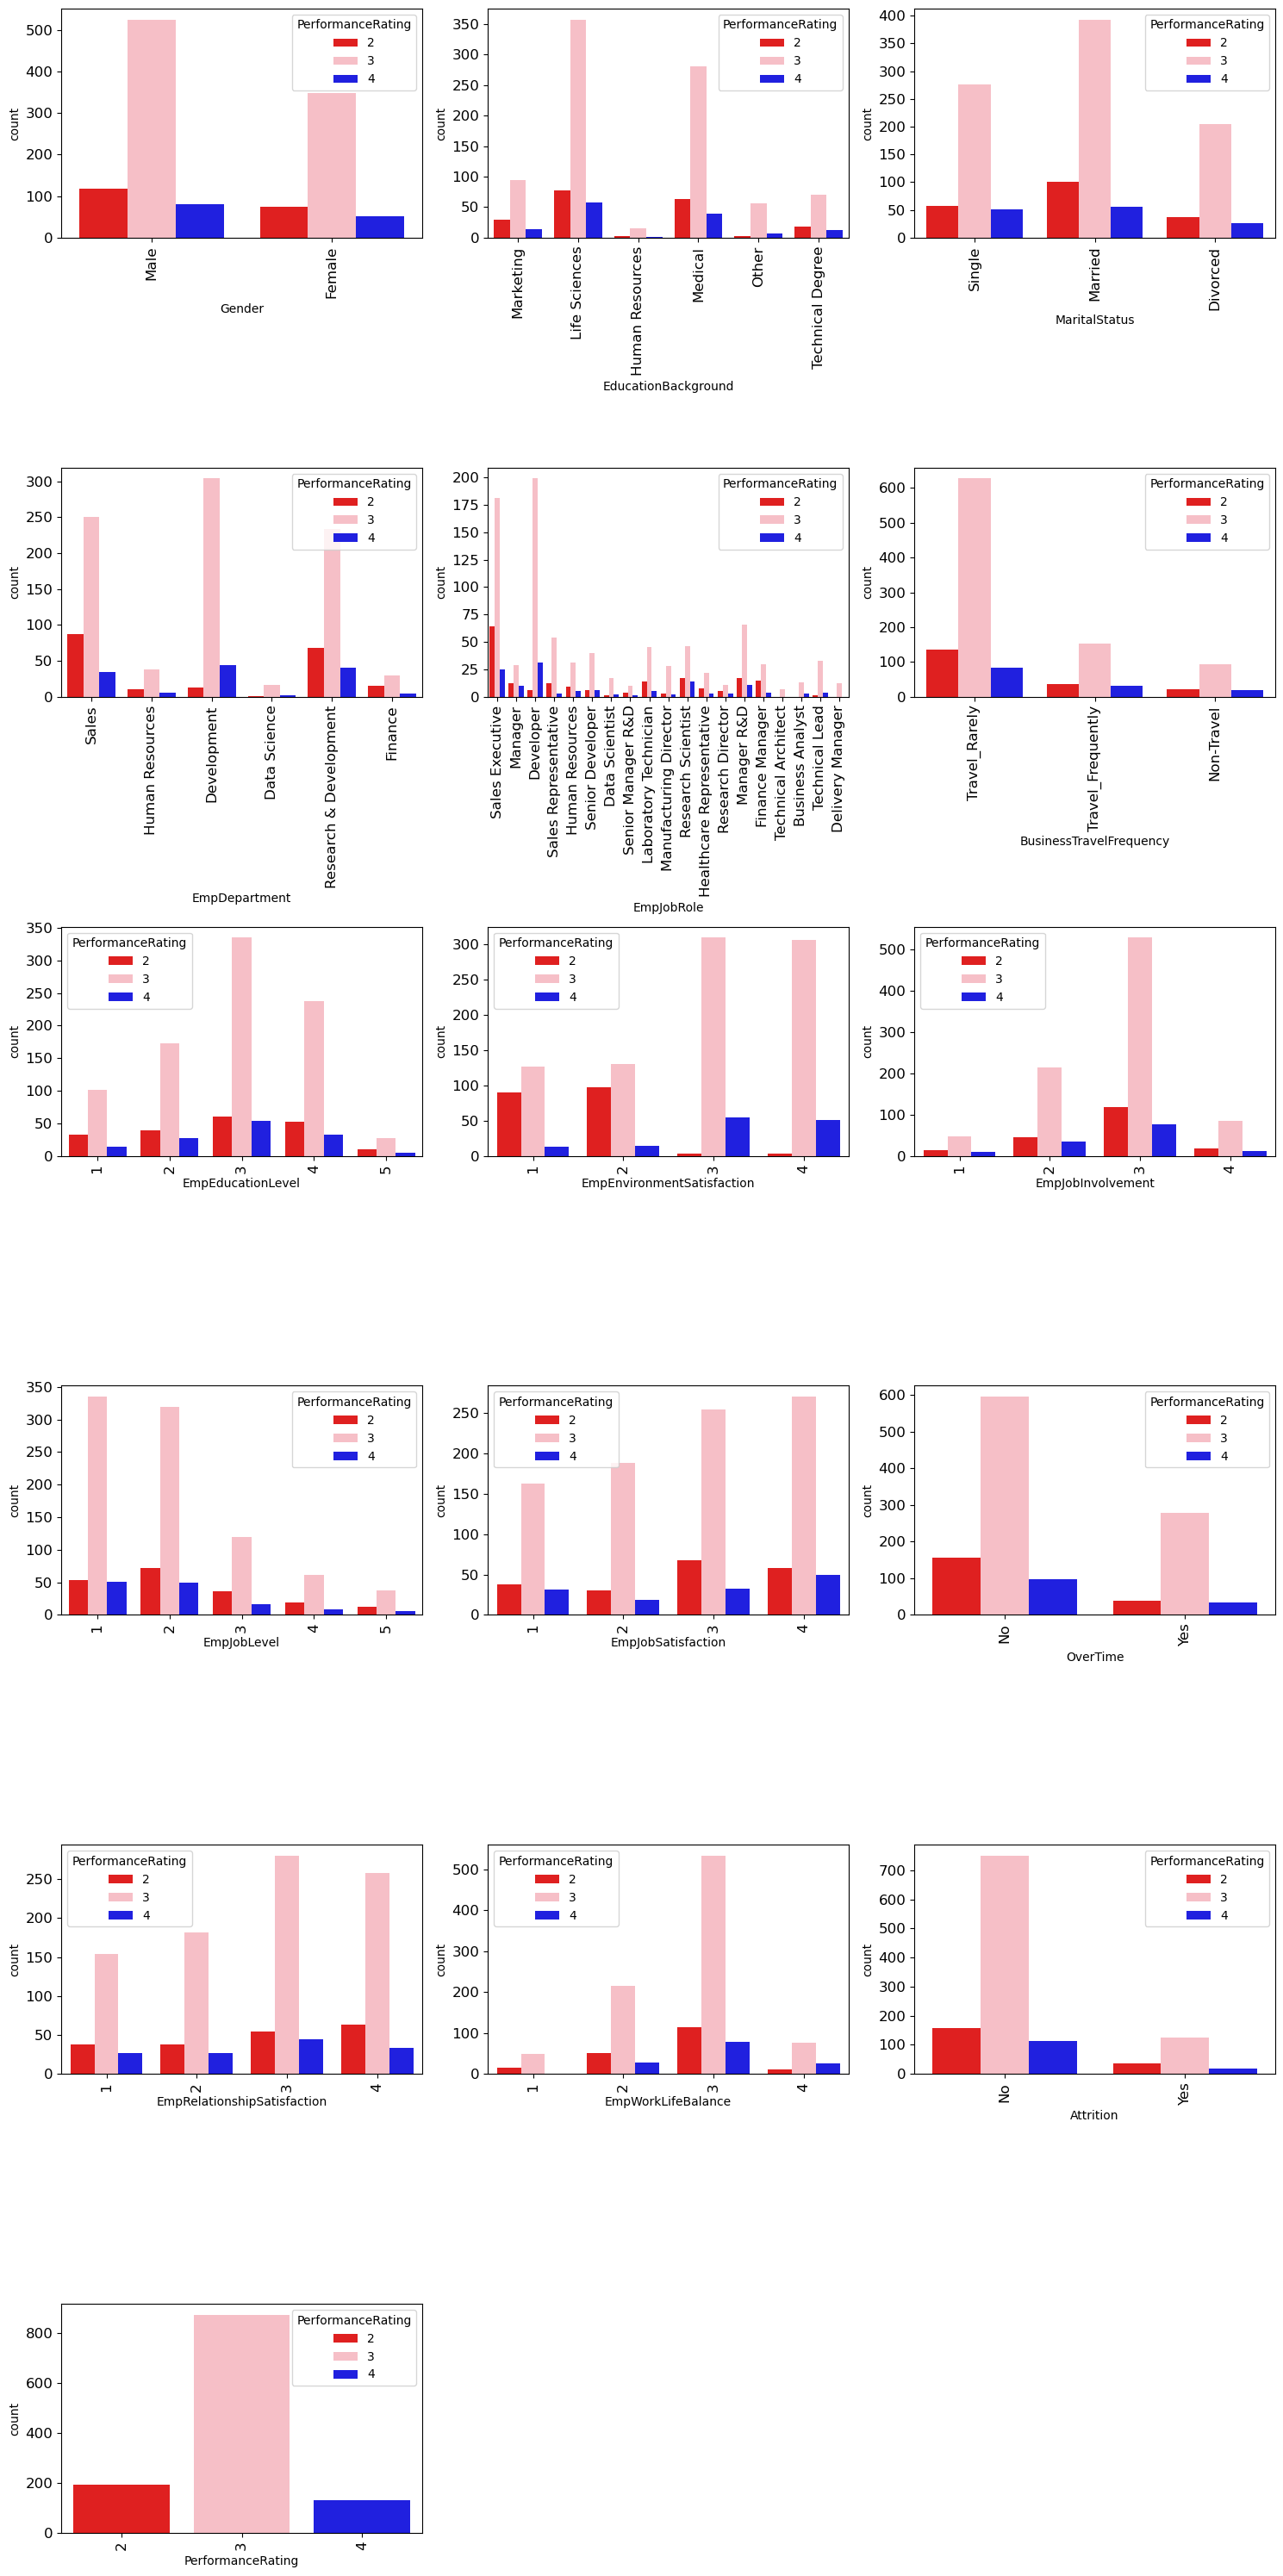

In [19]:
# Bivariate Analysis of Categorical Data
plt.figure(figsize=(15,30))                       
plotnumber = 1
for i in cat_data.columns :                     
    plt.subplot(6,3,plotnumber)                   
    sns.countplot(x = data[i],hue = data.PerformanceRating,palette=["red","lightpink","blue"])
    plt.xticks(rotation = 90,fontsize=12)         
    plt.yticks(fontsize=12)                     
    plotnumber = plotnumber + 1
plt.tight_layout() 

### Insights from Bivariate Analysis of Categorical Data :

- The Male and female are almost same in their performance.
- A majority of employees in the fields of Life Science, Medicine, and Marketing seem to have poor performance.
- married employees performance is bad.
- Employees in Sales and Research & Development departments seem to have poor performance.
- Sales Execuitive Employees performance is bad.
- Rarely travelling employee performance is poor.
- Employee whose eduaction level are 3 and 4 their performance seems to bad.
- who are not satisfied in job environment , their performance seems too bad.
- whose job involvment is low or high , their performance is bad.
- Employee whose job level on 5 their performance seems to bad.
- whose relationship satisfaction rate is low , their performance is also low.
- whose work life is not balanced , their performance seems to low.
- who have attrition in their work life, their performance seems to bad.

### Data Preprocessing 

In [20]:
data.isnull().sum()

Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

### Convert Categorical to Numerical

In [21]:
list(data.select_dtypes('object'))

['Gender',
 'EducationBackground',
 'MaritalStatus',
 'EmpDepartment',
 'EmpJobRole',
 'BusinessTravelFrequency',
 'OverTime',
 'Attrition']

#### 1.Gender

In [22]:
data.Gender.value_counts()

Gender
Male      725
Female    475
Name: count, dtype: int64

In [23]:
# Use mannual encoding to map the labels
data.Gender = data.Gender.map({'Male':1,'Female':0})

#### 2.Marital Status

In [24]:
data.MaritalStatus.value_counts()

MaritalStatus
Married     548
Single      384
Divorced    268
Name: count, dtype: int64

In [25]:
data.MaritalStatus = data.MaritalStatus.map({'Married':2,'Single':1,'Divorced':0})

In [26]:
data.MaritalStatus.value_counts()

MaritalStatus
2    548
1    384
0    268
Name: count, dtype: int64

#### 3.Business Travel Frequency

In [27]:
data.BusinessTravelFrequency.value_counts()

BusinessTravelFrequency
Travel_Rarely        846
Travel_Frequently    222
Non-Travel           132
Name: count, dtype: int64

In [28]:
data.BusinessTravelFrequency = data.BusinessTravelFrequency.map({'Travel_Rarely':2,'Travel_Frequently':1,'Non-Travel':0})

In [29]:
data.BusinessTravelFrequency.value_counts()

BusinessTravelFrequency
2    846
1    222
0    132
Name: count, dtype: int64

#### 4.Overtime

In [30]:
data.OverTime.value_counts()

OverTime
No     847
Yes    353
Name: count, dtype: int64

In [31]:
data.OverTime = data.OverTime.map({'No':1,'Yes':0})

In [32]:
data.OverTime.value_counts()

OverTime
1    847
0    353
Name: count, dtype: int64

#### 5.Attrition

In [33]:
data.Attrition.value_counts()

Attrition
No     1022
Yes     178
Name: count, dtype: int64

In [34]:
data.Attrition = data.Attrition.map({'No':1,'Yes':0})

In [35]:
data.Attrition.value_counts()

Attrition
1    1022
0     178
Name: count, dtype: int64

#### 6.Label Encoding of EducationBackground , EmpDepartment , EmpJobRole

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['EducationBackground'] = le.fit_transform(data['EducationBackground'])
data['EmpDepartment'] = le.fit_transform(data['EmpDepartment'])
data['EmpJobRole'] = le.fit_transform(data['EmpJobRole'])

In [37]:
data.dtypes

Age                             int64
Gender                          int64
EducationBackground             int64
MaritalStatus                   int64
EmpDepartment                   int64
EmpJobRole                      int64
BusinessTravelFrequency         int64
DistanceFromHome                int64
EmpEducationLevel               int64
EmpEnvironmentSatisfaction      int64
EmpHourlyRate                   int64
EmpJobInvolvement               int64
EmpJobLevel                     int64
EmpJobSatisfaction              int64
NumCompaniesWorked              int64
OverTime                        int64
EmpLastSalaryHikePercent        int64
EmpRelationshipSatisfaction     int64
TotalWorkExperienceInYears      int64
TrainingTimesLastYear           int64
EmpWorkLifeBalance              int64
ExperienceYearsAtThisCompany    int64
ExperienceYearsInCurrentRole    int64
YearsSinceLastPromotion         int64
YearsWithCurrManager            int64
Attrition                       int64
PerformanceR

### Checking Outliers

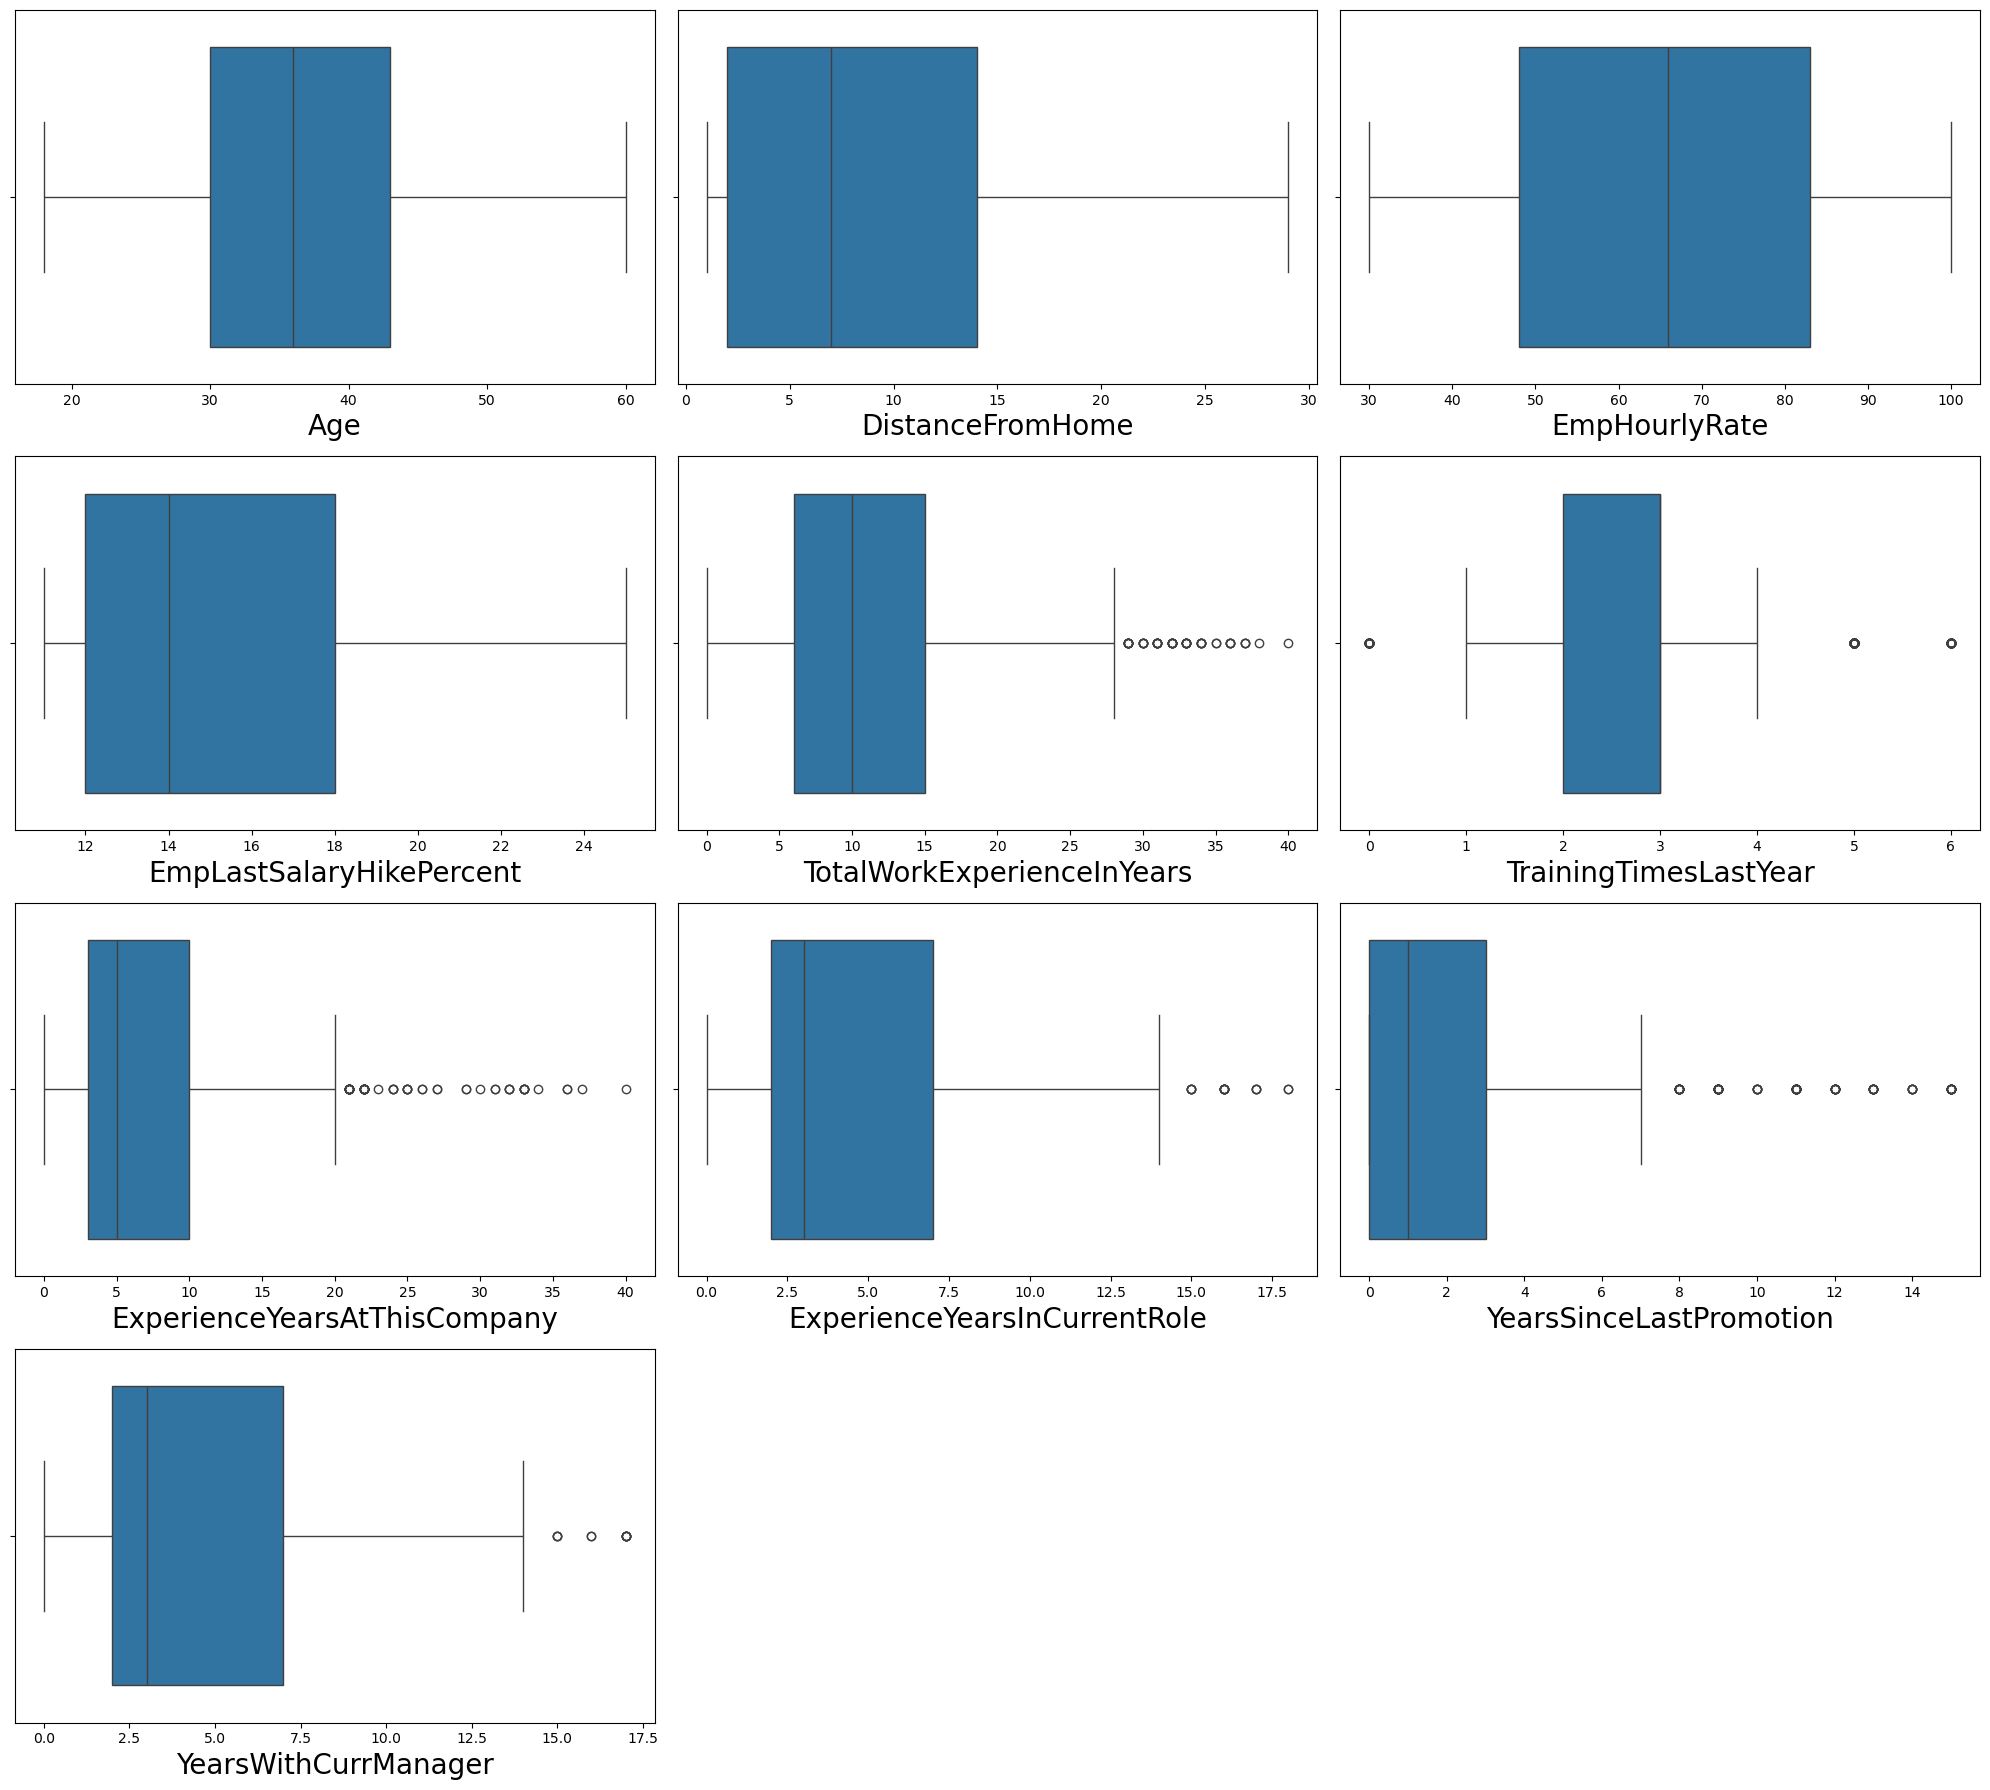

In [38]:
out = data[['Age','DistanceFromHome','EmpHourlyRate','EmpLastSalaryHikePercent',
                   'TotalWorkExperienceInYears','TrainingTimesLastYear','ExperienceYearsAtThisCompany',
                   'ExperienceYearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']]
plt.figure(figsize=(20,18)) 
plotno = 1 
for column in out: 
    if plotno<=12: 
        plt.subplot(4,3,plotno) 
        sns.boxplot(x=column,data=out)
        # sns.boxplot(out[column]) 
        plt.xlabel(column,fontsize=20)  
    plotno+=1 
plt.tight_layout()
plt.show() 

#### 1.Total Work Experiance in year

In [39]:
from scipy import stats
iqr = stats.iqr(data['TotalWorkExperienceInYears'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['TotalWorkExperienceInYears'].quantile(0.25)
Q3 = data['TotalWorkExperienceInYears'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 9.0
Minimum limit: -7.5
Maximum Limit: 28.5


In [40]:
data.loc[data['TotalWorkExperienceInYears'] > max_limit,'TotalWorkExperienceInYears']=data['TotalWorkExperienceInYears'].median()

In [41]:
data.loc[data['TotalWorkExperienceInYears'] > max_limit]

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating


#### 2.Training Time Last Year

In [42]:
iqr = stats.iqr(data['TrainingTimesLastYear'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['TrainingTimesLastYear'].quantile(0.25)
Q3 = data['TrainingTimesLastYear'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 1.0
Minimum limit: 0.5
Maximum Limit: 4.5


In [43]:
data.loc[data['TrainingTimesLastYear'] < min_limit,'TrainingTimesLastYear']=data['TrainingTimesLastYear'].median()
data.loc[data['TrainingTimesLastYear'] > max_limit,'TrainingTimesLastYear']=data['TrainingTimesLastYear'].median()

In [44]:
data.loc[data['TrainingTimesLastYear'] < min_limit]

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating


In [45]:
data[data['TrainingTimesLastYear'] > max_limit]

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating


#### 3.Experience Years At This Company

In [46]:
iqr = stats.iqr(data['ExperienceYearsAtThisCompany'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['ExperienceYearsAtThisCompany'].quantile(0.25)
Q3 = data['ExperienceYearsAtThisCompany'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 7.0
Minimum limit: -7.5
Maximum Limit: 20.5


In [47]:
data.loc[data['ExperienceYearsAtThisCompany'] > max_limit,'ExperienceYearsAtThisCompany']=data['ExperienceYearsAtThisCompany'].median()

In [48]:
data.loc[data['ExperienceYearsAtThisCompany'] > max_limit]

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating


#### 4.Experience Years In Current 

In [49]:
iqr = stats.iqr(data['ExperienceYearsInCurrentRole'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['ExperienceYearsInCurrentRole'].quantile(0.25)
Q3 = data['ExperienceYearsInCurrentRole'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 5.0
Minimum limit: -5.5
Maximum Limit: 14.5


In [50]:
data.loc[data['ExperienceYearsInCurrentRole'] > max_limit,'ExperienceYearsInCurrentRole'] = data['ExperienceYearsInCurrentRole'].median()

In [51]:
data.loc[data['ExperienceYearsInCurrentRole'] > max_limit]

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating


#### 5.Years Since Last Promotion

In [52]:
iqr = stats.iqr(data['YearsSinceLastPromotion'],interpolation='midpoint')
print("IQR:",iqr)

# Get first and third quantile
Q1 = data['YearsSinceLastPromotion'].quantile(0.25)
Q3 = data['YearsSinceLastPromotion'].quantile(0.75)

# Get manimum and maximum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 +1.5*iqr
print("Maximum limit",max_limit)

IQR: 3.0
Minimum limit: -4.5
Maximum limit 7.5


In [53]:
data.loc[data['YearsSinceLastPromotion'] > max_limit,'YearsSinceLastPromotion']=data['YearsSinceLastPromotion'].median()

In [54]:
data.loc[data['YearsSinceLastPromotion'] > max_limit]

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating


#### 6.Years With Current Manager

In [55]:
iqr = stats.iqr(data['YearsWithCurrManager'],interpolation='midpoint')
print("IQR:",iqr)

# Get first and third quantile
Q1 = data['YearsWithCurrManager'].quantile(0.25)
Q3 = data['YearsWithCurrManager'].quantile(0.75)

# Get manimum and maximum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 +1.5*iqr
print("Maximum limit",max_limit)

IQR: 5.0
Minimum limit: -5.5
Maximum limit 14.5


In [56]:
data.loc[data['YearsWithCurrManager'] > max_limit,'YearsWithCurrManager']=data['YearsWithCurrManager'].median()

In [57]:
data.loc[data['YearsWithCurrManager'] >max_limit]

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating


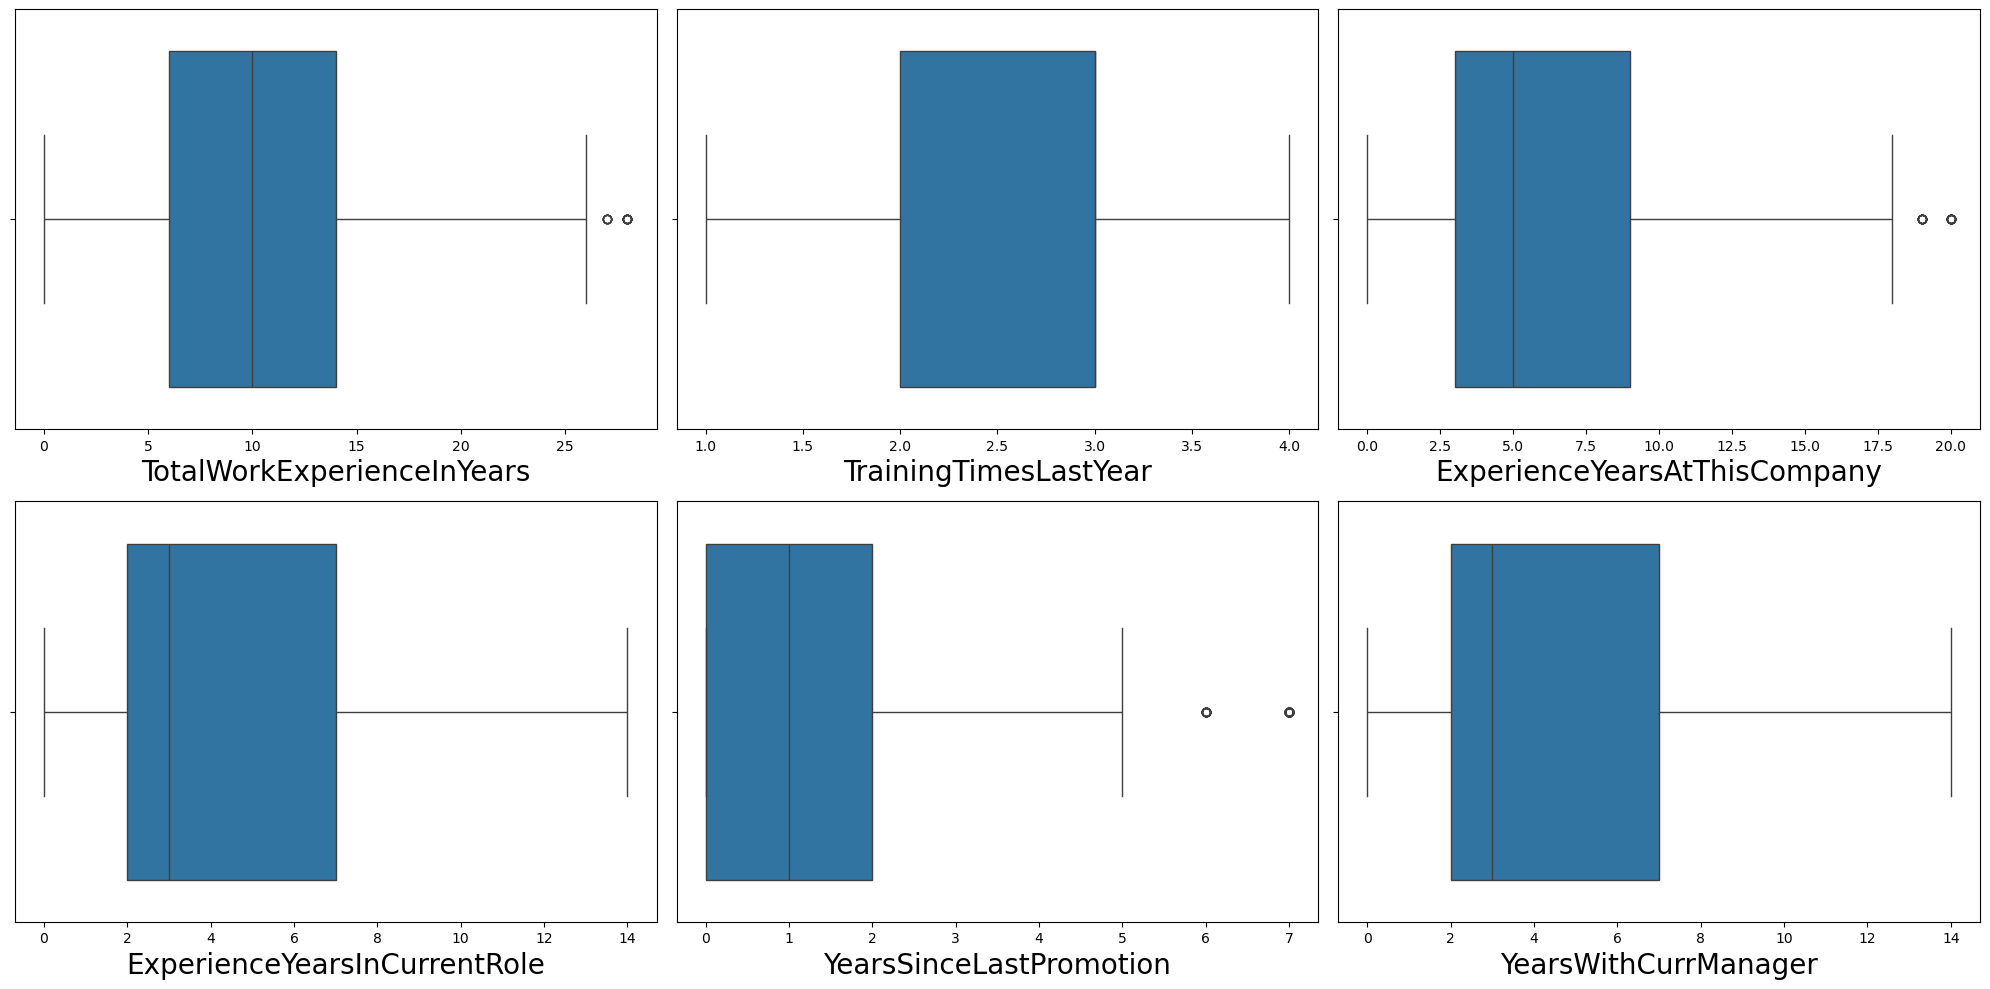

In [58]:
out = data[['TotalWorkExperienceInYears','TrainingTimesLastYear','ExperienceYearsAtThisCompany',
            'ExperienceYearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']]

plt.figure(figsize=(20,10)) 
plotno = 1 

for column in out:
    if plotno<=7:    
        plt.subplot(2,3,plotno) 
        sns.boxplot(x=column,data=out) 
        plt.xlabel(column,fontsize=20)  
    plotno+=1 
plt.tight_layout()
plt.show() 

Outliers have been handled using the IQR method, which reduced extreme values and made the data more consistent. However, a few points still appear in the boxplot, but these are not true outliers—they fall within the acceptable range. Most features now show a balanced distribution, especially in experience-related columns. The data is less skewed and more reliable for further analysis and model building.

### Checking Correlation

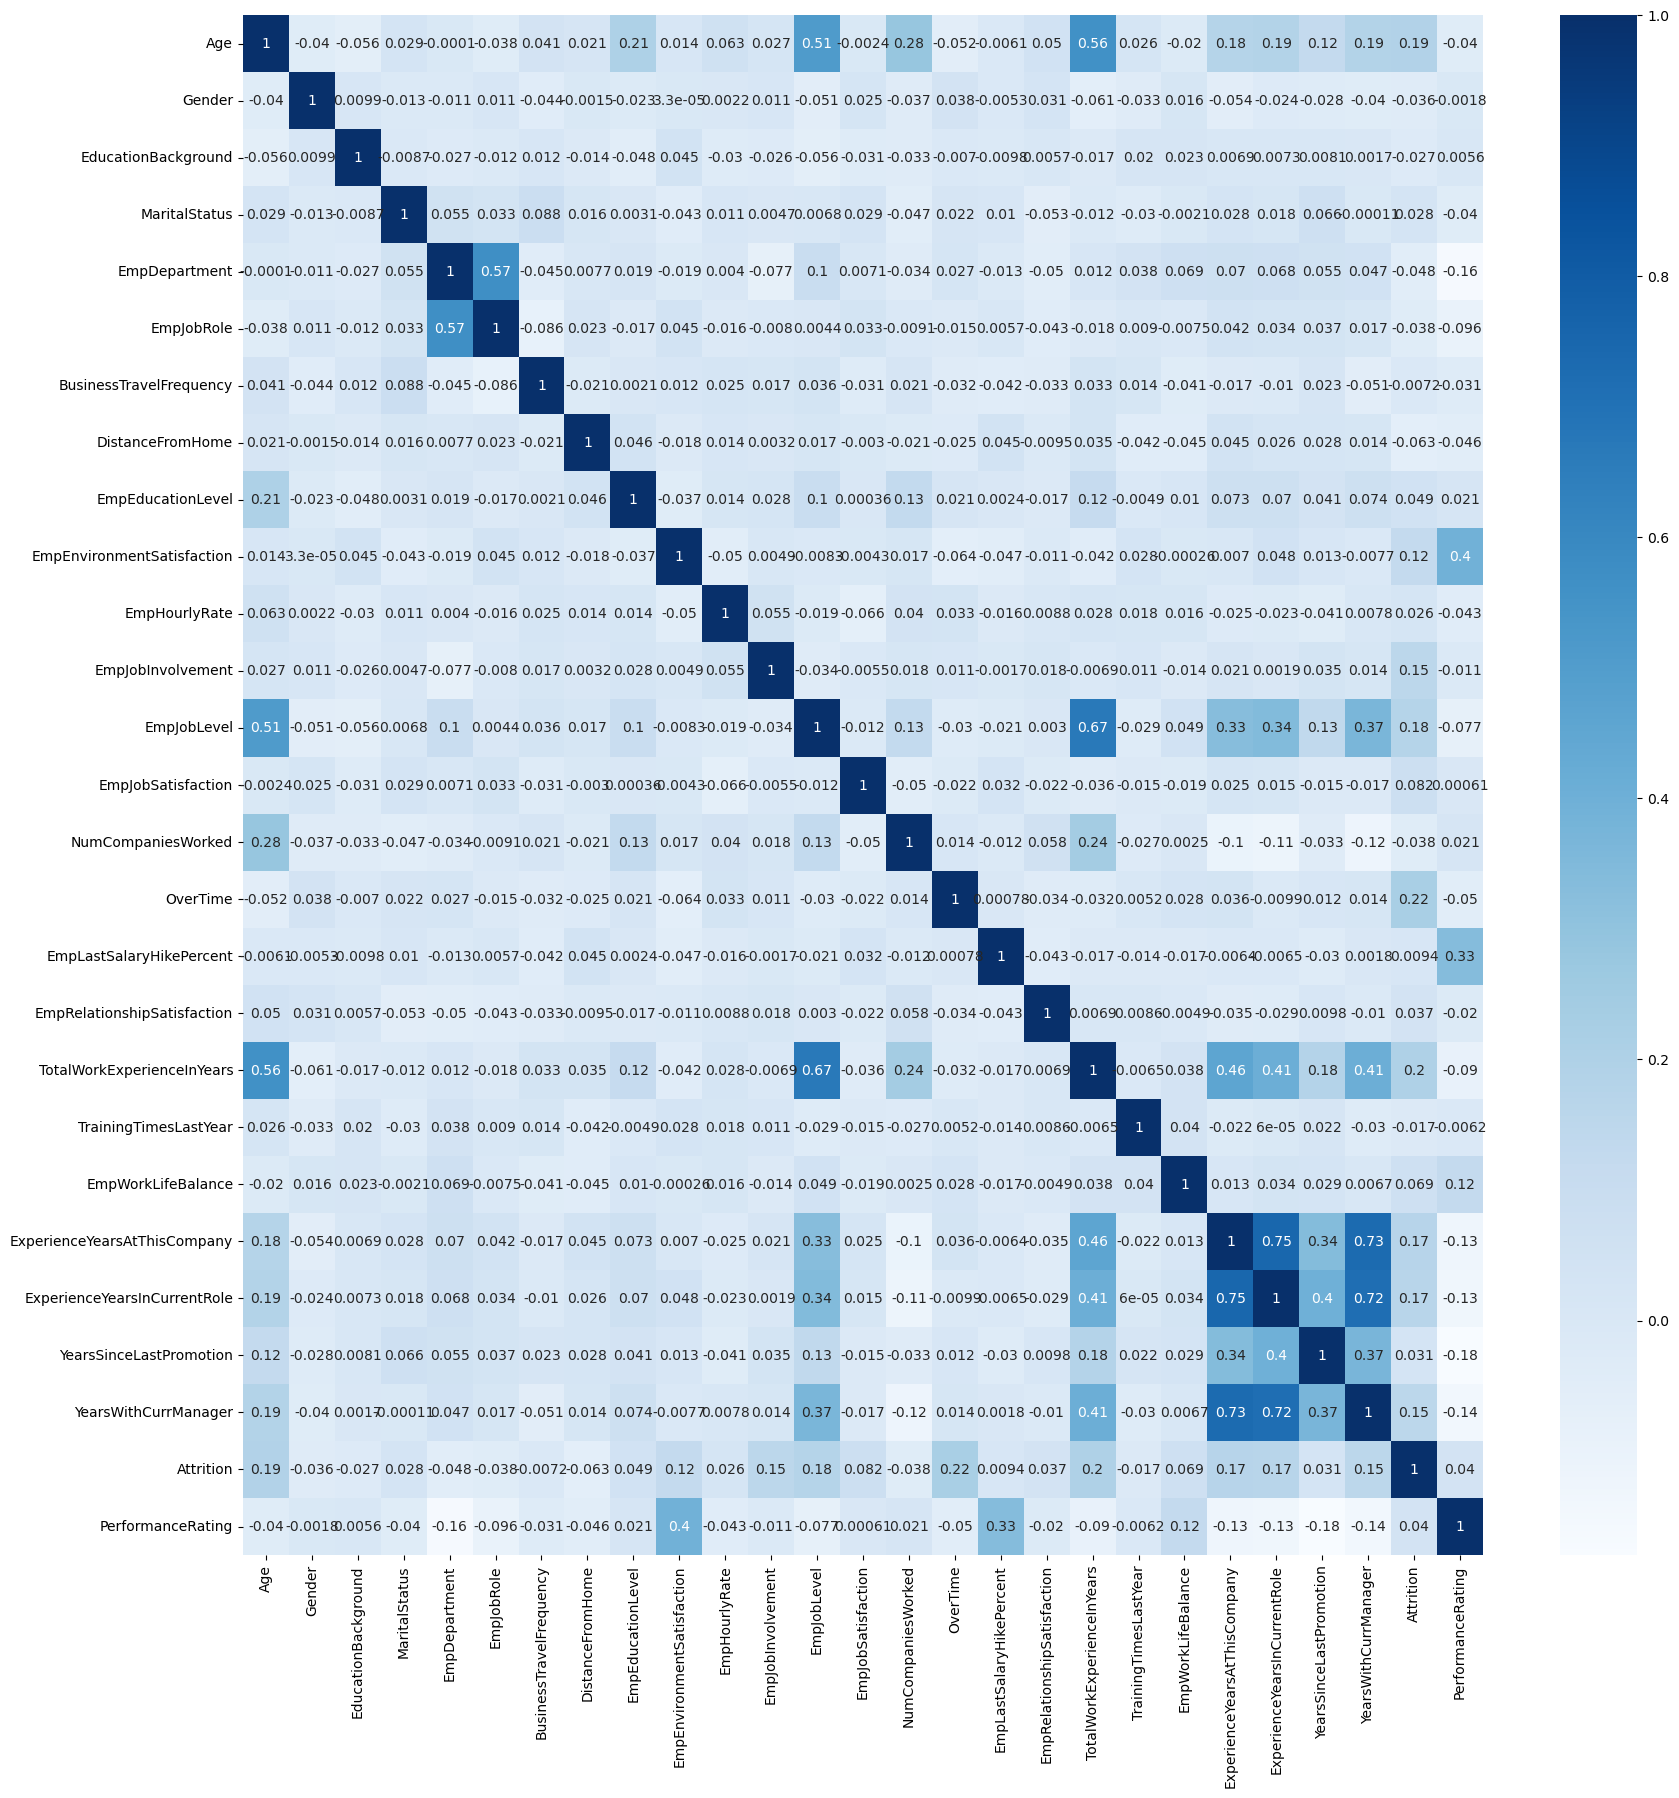

In [59]:
plt.figure(figsize=(20,20))
sns.heatmap(data.corr(),annot=True,cmap='Blues')
plt.show()

- From above heatmap scale we are clearly seen the their is no highly correlated feature in data

### Model Creation

In [60]:
X = data.drop(['PerformanceRating'],axis=1)
y = data['PerformanceRating']

In [61]:
X.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,32,1,2,1,5,13,2,10,3,4,55,3,2,4,1,1,12,4,10,2,2,10,7,0,8,1
1,47,1,2,1,5,13,2,14,4,4,42,3,2,1,2,1,12,4,20,2,3,7,7,1,7,1
2,40,1,1,2,5,13,1,5,4,4,48,2,3,1,5,0,21,3,20,2,3,18,13,1,12,1
3,41,1,0,0,3,8,2,10,4,2,73,2,5,4,3,1,15,2,23,2,2,5,6,1,6,1
4,60,1,2,1,5,13,2,16,4,1,84,3,2,1,8,1,14,4,10,1,3,2,2,2,2,1


In [62]:
y.head()

0    3
1    3
2    4
3    3
4    3
Name: PerformanceRating, dtype: int64

In [63]:
y.value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [64]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_smote , y_smote = smote.fit_resample(X, y)

y_smote.value_counts()

PerformanceRating
3    874
4    874
2    874
Name: count, dtype: int64

In [65]:
# Split Data into Train and Test

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_smote,y_smote,test_size=0.2,random_state=42)

In [66]:
from sklearn.metrics import classification_report, recall_score,confusion_matrix, accuracy_score, roc_auc_score

#### Logistic Regression

In [67]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000,
    class_weight='balanced',
    multi_class='auto')

lr.fit(X_train,y_train)

y_pred_lr= lr.predict(X_test)
acc_lr = accuracy_score(y_test,y_pred_lr )
print("Accuracy of Logistic Regression:",acc_lr )
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr ))

Accuracy of Logistic Regression: 0.8247619047619048

Classification Report:
               precision    recall  f1-score   support

           2       0.84      0.88      0.86       184
           3       0.84      0.71      0.76       173
           4       0.81      0.89      0.84       168

    accuracy                           0.82       525
   macro avg       0.83      0.82      0.82       525
weighted avg       0.83      0.82      0.82       525



In [68]:
from sklearn.metrics import f1_score
f1_lr = f1_score(y_test , y_pred_lr , average='weighted')
print("f1_score of  lr boost: " , f1_lr)

f1_score of  lr boost:  0.8225993659605627


#### Hyperparameter Tunning of LR

In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

Log_Hyperpara = {
    'C': [0.001, 0.01, 0.1, 1, 10, 1000],                 
    'solver': ['lbfgs', 'liblinear', 'saga'],             
    'max_iter':[100,200,400,600,800,1000],                
    'multi_class':['ovr','multinomial']                   
}

Lr_grid = GridSearchCV(LogisticRegression(random_state=0),         
                       param_grid=Log_Hyperpara,      
                       scoring='accuracy',            
                       cv=3,                          
                       verbose=3,                     
                       n_jobs=-1                     
                       )

Lr_grid.fit(X_train,y_train)

print(f"Best Score: {Lr_grid.best_score_})")        
print(f"Best paramters: {Lr_grid.best_params_})") 

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Score: 0.8311874105865522)
Best paramters: {'C': 1000, 'max_iter': 800, 'multi_class': 'ovr', 'solver': 'lbfgs'})


In [70]:
lr_hyp = LogisticRegression(C= 0.1, max_iter =  500, multi_class = 'multinomial', solver = 'lbfgs')
lr_hyp.fit(X_train, y_train)

# Evaluate the final model on the test data
y_hyp_lr = lr_hyp.predict(X_test)
acc_hyp_lr = accuracy_score(y_test, y_hyp_lr)

print("Accuracy of LR after Hyperparameter Tuning:", acc_hyp_lr )

Accuracy of LR after Hyperparameter Tuning: 0.8228571428571428


#### Decision Tree

In [71]:
from sklearn.tree import DecisionTreeClassifier         
dt = DecisionTreeClassifier(random_state=2)           
dt.fit(X_train,y_train)                                
y_pr_dt = dt.predict(X_test) 

In [72]:
acc_dt = accuracy_score(y_test,y_pr_dt)
print("Accuracy of Decision Tree : ",acc_dt)
print("\nClassification Report:\n",classification_report(y_test,y_pr_dt))

Accuracy of Decision Tree :  0.9123809523809524

Classification Report:
               precision    recall  f1-score   support

           2       0.94      0.96      0.95       184
           3       0.91      0.84      0.87       173
           4       0.89      0.94      0.91       168

    accuracy                           0.91       525
   macro avg       0.91      0.91      0.91       525
weighted avg       0.91      0.91      0.91       525



In [73]:
# test F1 Score
f1_dt = f1_score(y_test , y_pr_dt , average='weighted')
print("f1_score of Decision Tree : " , f1_dt)

f1_score of Decision Tree :  0.9117247823325837


#### Hyperparameter Tuning of DT

In [74]:
Tree_Hyperpara ={
    'criterion': ['gini', 'entropy'],                
    'max_depth': [None,range(1, 20)],               
    'splitter': ['best', 'random'],                  
    'max_features': ['auto', 'sqrt', 'log2', None],  
    'min_samples_split': [2, 5, 10],                 
    'min_samples_leaf': list(range(1, 11))          
}


# Perform grid search with cross-validation
Tree_grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=2),
                               param_grid=Tree_Hyperpara,      
                               cv=3,                           
                               scoring='accuracy',             
                               n_jobs=-1,
                               verbose=1)

#training data on gridsearch cv
Tree_grid_search.fit(X_train,y_train)

# print best score and parameters
print("Best Accuracy:", Tree_grid_search.best_score_)
print("Best Hyperparameters:", Tree_grid_search.best_params_)

Fitting 3 folds for each of 960 candidates, totalling 2880 fits
Best Accuracy: 0.9136862184072485
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2, 'splitter': 'best'}


In [75]:
dt_hyp = DecisionTreeClassifier(criterion='entropy',max_depth=None,max_features=None,
                                  min_samples_leaf=3,min_samples_split=10,splitter='best',random_state=23)
dt_hyp.fit(X_train,y_train)
y_hyp_dt = dt_hyp.predict(X_test)

# check performance of Decision Tree model
acc_hyp_dt = accuracy_score(y_test,y_hyp_dt)
print("Accuracy of Decision Tree after Hyperparameter : ",acc_hyp_dt)
print(classification_report(y_test,y_hyp_dt))

Accuracy of Decision Tree after Hyperparameter :  0.8876190476190476
              precision    recall  f1-score   support

           2       0.93      0.93      0.93       184
           3       0.85      0.84      0.85       173
           4       0.88      0.89      0.88       168

    accuracy                           0.89       525
   macro avg       0.89      0.89      0.89       525
weighted avg       0.89      0.89      0.89       525



#### Random Forest

In [76]:
from sklearn.ensemble import RandomForestClassifier   
rf = RandomForestClassifier(random_state=1)        
rf.fit(X_train,y_train)                            
y_pr_rf = rf.predict(X_test)     

acc_rf = accuracy_score(y_test,y_pr_rf)
print("Accuracy of Random Forest :  ",acc_rf)
print("\nClassification Report:\n",classification_report(y_test,y_pr_rf))

Accuracy of Random Forest :   0.9619047619047619

Classification Report:
               precision    recall  f1-score   support

           2       0.97      0.98      0.98       184
           3       0.96      0.93      0.94       173
           4       0.95      0.98      0.96       168

    accuracy                           0.96       525
   macro avg       0.96      0.96      0.96       525
weighted avg       0.96      0.96      0.96       525



In [77]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

importance = pd.Series(result.importances_mean, index=X.columns)
top3 = importance.sort_values(ascending=False).head(3)

print(top3)

EmpEnvironmentSatisfaction    0.262286
EmpLastSalaryHikePercent      0.248381
YearsSinceLastPromotion       0.139429
dtype: float64


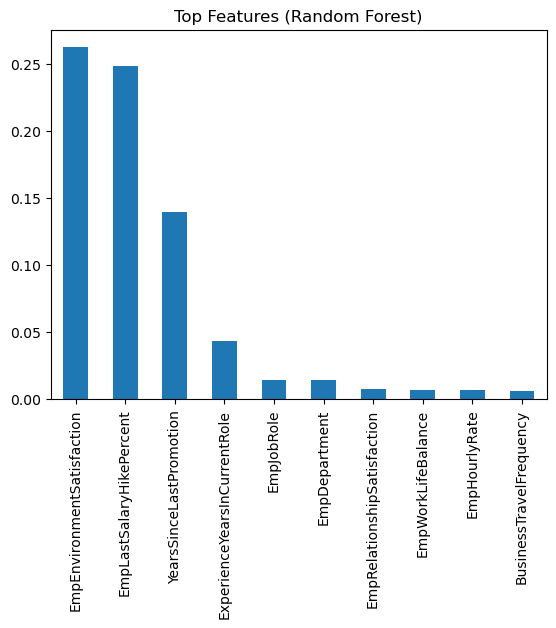

In [78]:
import matplotlib.pyplot as plt

importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features (Random Forest)")
plt.show()

In [79]:
f1_rf = f1_score(y_test , y_pr_rf , average='weighted')
print("f1_score of Random Forest : " , f1_rf)

f1_score of Random Forest :  0.9617971184182135


#### Hyperparameter Tuning of RF

In [80]:
Forest_Hyperparameter = {
    'n_estimators': [50, 100, 200,300,400,500],        
    'max_depth': [None, range(1,20)],                 
    'min_samples_split': [2, 5, 10],                   
    'min_samples_leaf': [1, 2, 4],                    
    'max_features': ['auto', 'sqrt', 'log2']          
}

# Perform grid search with cross-validation
forest_random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=31),
                                         param_distributions=Forest_Hyperparameter,
                                         n_iter=100,
                                         n_jobs=-1,
                                         scoring='accuracy' ,
                                         cv=3,
                                         verbose=3,random_state=0)

# Train random random search
forest_random_search.fit(X_train,y_train)

# print best parameters and score
print("Best Score:", forest_random_search.best_score_)
print("Best Hyperparameters:", forest_random_search.best_params_)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Score: 0.9546971864568431
Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [81]:
hyp_forest = RandomForestClassifier(n_estimators=200,min_samples_split=2,min_samples_leaf=1,
                                max_features='log2',max_depth=None,random_state=3)
hyp_forest.fit(X_train,y_train)
y_hyp_forest = hyp_forest.predict(X_test)

# Check Performance
acc_hyp_rf = accuracy_score(y_test,y_hyp_forest)
print("Accuracy of Random Forest After Hyperparameter Tunning :  ",acc_hyp_rf)

Accuracy of Random Forest After Hyperparameter Tunning :   0.9657142857142857


#### Gradient Boosting

In [82]:
from sklearn.ensemble import GradientBoostingClassifier   
gb = GradientBoostingClassifier(random_state=0)          
gb.fit(X_train,y_train)                                  
y_pr_gb = gb.predict(X_test)    

acc_gb = accuracy_score(y_test,y_pr_gb)
print("Accuracy of Gradient Boost : ",acc_gb)
print("\nClassification Report:\n",classification_report(y_test , y_pr_gb))

Accuracy of Gradient Boost :  0.9485714285714286

Classification Report:
               precision    recall  f1-score   support

           2       0.97      0.98      0.97       184
           3       0.93      0.91      0.92       173
           4       0.94      0.95      0.95       168

    accuracy                           0.95       525
   macro avg       0.95      0.95      0.95       525
weighted avg       0.95      0.95      0.95       525



In [83]:
f1_gb = f1_score(y_test , y_pr_gb , average='weighted')
print("f1_score of  Gradient Boost: " , f1_gb)

f1_score of  Gradient Boost:  0.9484347327262306


#### Hyperparameter Tuning of GB

In [84]:
GB_hyperpara = {
    'n_estimators': [50, 100, 200,300,400,500],        
    'max_depth': [None, range(1,20)],                  
    'min_samples_split': [2, 5, 10],                   
    'min_samples_leaf': [1, 2, 4],                     
    'max_features': ['auto', 'sqrt', 'log2']           
}

GB_Grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=0),
                             param_grid=GB_hyperpara,
                             cv=3,
                             scoring='accuracy',
                             verbose=3,n_jobs=-1)

GB_Grid_search.fit(X_train,y_train)

print("Best Score : ",GB_Grid_search.best_score_)
print("Best Parameters : ",GB_Grid_search.best_params_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best Score :  0.9637577491654744
Best Parameters :  {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}


In [85]:
hyp_gbc = RandomForestClassifier(n_estimators=500,min_samples_split=5,min_samples_leaf=2,
                                max_features='log2',max_depth=None,random_state=0)
hyp_gbc.fit(X_train,y_train)
y_hyp_gbc = hyp_gbc.predict(X_test)

# Check Performance
acc_hyp_gb = accuracy_score(y_test,y_hyp_gbc)
print("Accuracy of Gradient Boost After Hyperparameter Tunning :  ",acc_hyp_gb)

Accuracy of Gradient Boost After Hyperparameter Tunning :   0.9619047619047619


#### XGB

In [86]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [87]:
from xgboost import XGBClassifier        
xgb = XGBClassifier()                    
xgb.fit(X_train,y_train)                 
y_pr_xgb = xgb.predict(X_test)  

acc_xgb = accuracy_score(y_test,y_pr_xgb)
print("Accuracy of XGBClassifier :  ",acc_xgb)
print("\nClassification Report:\n",classification_report(y_test,y_pr_xgb))

Accuracy of XGBClassifier :   0.9561904761904761

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       184
           1       0.95      0.92      0.94       173
           2       0.95      0.97      0.96       168

    accuracy                           0.96       525
   macro avg       0.96      0.96      0.96       525
weighted avg       0.96      0.96      0.96       525



In [88]:
f1_xgb = f1_score(y_test , y_pr_xgb , average='weighted')
print("f1_score of  XG boost: " , f1_xgb)

f1_score of  XG boost:  0.9560824745637074


#### Hyperparameter Tuning Of XGB

In [89]:
xgb_hyperpara = {'gamma': [0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25,50,100],
              'learning_rate': [0.01, 0.03, 0.06, 0.1, 0.15, 0.2, 0.25, 0.30, 0.4, 0.5, 0.6, 0.7],
              'max_depth': [None,range(1,20)],
              'n_estimators': [50,100,150,200,250,300],
              'reg_alpha': [0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200],
              'reg_lambda': [0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200]}

xgb_random_search= RandomizedSearchCV(estimator=XGBClassifier(random_state=2),
                                      param_distributions=xgb_hyperpara,        
                                      scoring='accuracy',                       
                                      n_iter=100,                               
                                      cv=3,                                    
                                      verbose=2,                      
                                      random_state=3,
                                      n_jobs=-1)                      

# training data on randomsearch cv
xgb_random_search.fit(X_train, y_train)

# Print best score and parameters
print(f"Best Score : {xgb_random_search.best_score_}")
print(f"Best paramters: {xgb_random_search.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Score : 0.9499284692417739
Best paramters: {'reg_lambda': 0.8, 'reg_alpha': 0.2, 'n_estimators': 200, 'max_depth': None, 'learning_rate': 0.4, 'gamma': 0}


In [90]:
Xgb_hyp=XGBClassifier(reg_lambda= 1, reg_alpha= 0.1, n_estimators=130, max_depth=None, learning_rate= 0.6, gamma=0.1)
Xgb_hyp.fit(X_train, y_train)
y_hyp_xgb=Xgb_hyp.predict(X_test)

acc_hyp_xgb = accuracy_score(y_hyp_xgb,y_test)
print("Accuracy of XGBClassifier after Hyperparameter Tunning : ",acc_hyp_xgb)

Accuracy of XGBClassifier after Hyperparameter Tunning :  0.9504761904761905


#### KNN

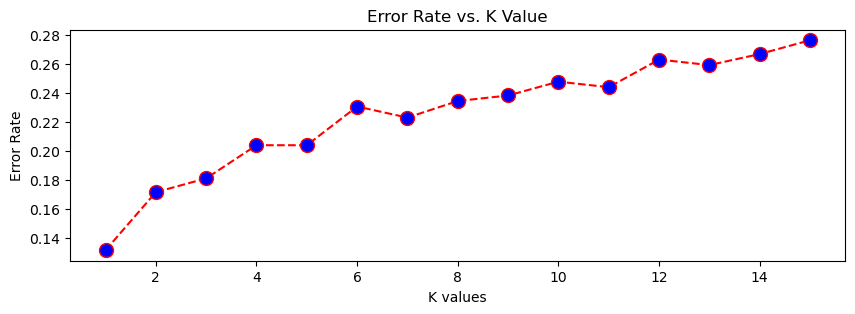

In [91]:
from sklearn.neighbors import KNeighborsClassifier              
Error_rate = []                                                  
for K in range(1,16):                                            
    model = KNeighborsClassifier(n_neighbors=K)                  
    model.fit(X_train,y_train)                                   
    y_pred = model.predict(X_test)                               
    Error_rate.append(np.mean(y_pred != y_test))                 


plt.figure(figsize=(10,3))
plt.plot(range(1,16),Error_rate,linestyle='dashed',color='red',marker='o',markerfacecolor='blue',markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K values')
plt.ylabel('Error Rate')
plt.show()

In [92]:
knn = KNeighborsClassifier(n_neighbors=3)                  
knn.fit(X_train,y_train)                                   
y_pred_knn = knn.predict(X_test)                            
acc_knn = accuracy_score(y_pred_knn,y_test)                  
print("Accuracy of K nearest Neighbour : ",acc_knn)
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn ))

Accuracy of K nearest Neighbour :  0.819047619047619

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.99      0.84       184
           1       0.99      0.47      0.64       173
           2       0.85      0.99      0.92       168

    accuracy                           0.82       525
   macro avg       0.86      0.82      0.80       525
weighted avg       0.86      0.82      0.80       525



In [93]:
f1_knn = f1_score(y_test,y_pred_knn,average='weighted')
print("f1_score of K neighbour : ",f1_knn)

f1_score of K neighbour :  0.7989647242798602


#### Hyperparameter Tuning of KNN

In [94]:
Knn_Hyperpara = {
    'n_neighbors': range(1, 21),                       
    'weights':['uniform','distance'],                  
    'metric': ['euclidean', 'manhattan', 'minkowski']  
}

# Perform grid search by defining all parameters
Knn_grid_search = GridSearchCV(estimator=KNeighborsClassifier(), 
                               param_grid=Knn_Hyperpara,         
                               cv=3,                             
                               scoring='accuracy',               
                               verbose=3)

# train grid to find best parameters
Knn_grid_search.fit(X_train,y_train)

print("Best Hyperparameters:", Knn_grid_search.best_params_)
print("Best Accuracy:", Knn_grid_search.best_score_)

Fitting 3 folds for each of 120 candidates, totalling 360 fits
[CV 1/3] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.844 total time=   0.0s
[CV 2/3] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.845 total time=   0.0s
[CV 3/3] END metric=euclidean, n_neighbors=1, weights=uniform;, score=0.851 total time=   0.0s
[CV 1/3] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.844 total time=   0.0s
[CV 2/3] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.845 total time=   0.0s
[CV 3/3] END metric=euclidean, n_neighbors=1, weights=distance;, score=0.851 total time=   0.0s
[CV 1/3] END metric=euclidean, n_neighbors=2, weights=uniform;, score=0.801 total time=   0.0s
[CV 2/3] END metric=euclidean, n_neighbors=2, weights=uniform;, score=0.815 total time=   0.0s
[CV 3/3] END metric=euclidean, n_neighbors=2, weights=uniform;, score=0.808 total time=   0.0s
[CV 1/3] END metric=euclidean, n_neighbors=2, weights=distance;, score=0.844 to

In [95]:
knn_hyp = KNeighborsClassifier(n_neighbors=3,metric='manhattan',weights='distance')
knn_hyp.fit(X_train,y_train)                                    # train KNN model
y_hyp_knn = knn_hyp.predict(X_test)                             # make prediction for test data
acc_hyp_knn = accuracy_score(y_hyp_knn,y_test)                  # check performance
print("Accuracy of KNN after Hyperparameter Tuning: ",acc_hyp_knn)
print(classification_report(y_test,y_hyp_knn))

Accuracy of KNN after Hyperparameter Tuning:  0.8361904761904762
              precision    recall  f1-score   support

           0       0.78      1.00      0.88       184
           1       1.00      0.50      0.67       173
           2       0.83      1.00      0.91       168

    accuracy                           0.84       525
   macro avg       0.87      0.83      0.82       525
weighted avg       0.87      0.84      0.82       525



#### SVC

In [96]:
from sklearn.svm import SVC                               # import SVC
svc = SVC(decision_function_shape='ovr',random_state=1)   # define SVC for multiclass
svc.fit(X_train,y_train)                                  # Train SVC model
y_pr_svc = svc.predict(X_test)                            # make Prediction

# check performance ofd SVC model
acc_svc = accuracy_score(y_test,y_pr_svc)
print("Accuracy of SVC : ",acc_svc)
print("\nClassification Report:\n",classification_report(y_test,y_pr_svc))

Accuracy of SVC :  0.7219047619047619

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.74      0.73       184
           1       0.73      0.52      0.61       173
           2       0.72      0.91      0.81       168

    accuracy                           0.72       525
   macro avg       0.72      0.72      0.71       525
weighted avg       0.72      0.72      0.71       525



In [97]:
f1_svc = f1_score(y_test,y_pr_svc,average='weighted')
print("f1_score of SVC : ",f1_svc)

f1_score of SVC :  0.7129620858041911


#### Hyperparameter Tuning Of SVC

In [98]:
Svc_Hyperpara = {
    'C': [0.0001, 0.001, 0.1, 1, 10, 100],              # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],                # Kernel functions to consider
    'gamma': [0.1, 1, 'scale', 'auto'],                 # Kernel coefficient for rbf and poly kernels
}


# Perform grid search with cross-validation
Svc_grid_search = GridSearchCV(estimator=SVC(),               # estimator or model
                               param_grid=Svc_Hyperpara,      # hyperparametes(dictionary we created)
                               cv=3,                          # number of folds
                               scoring='accuracy',            # performance matrix to check performance
                              verbose=3)

# Train grid to find best models
Svc_grid_search.fit(X_train, y_train)

print("Best Score : ",Svc_grid_search.best_score_)
print("Best Parameters : ",Svc_grid_search.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV 1/3] END C=0.0001, gamma=0.1, kernel=linear;, score=0.629 total time=   0.0s
[CV 2/3] END C=0.0001, gamma=0.1, kernel=linear;, score=0.690 total time=   0.0s
[CV 3/3] END C=0.0001, gamma=0.1, kernel=linear;, score=0.647 total time=   0.0s
[CV 1/3] END ...C=0.0001, gamma=0.1, kernel=rbf;, score=0.336 total time=   0.1s
[CV 2/3] END ...C=0.0001, gamma=0.1, kernel=rbf;, score=0.336 total time=   0.1s
[CV 3/3] END ...C=0.0001, gamma=0.1, kernel=rbf;, score=0.338 total time=   0.1s
[CV 1/3] END ..C=0.0001, gamma=0.1, kernel=poly;, score=0.854 total time=   3.7s
[CV 2/3] END ..C=0.0001, gamma=0.1, kernel=poly;, score=0.884 total time=   4.8s
[CV 3/3] END ..C=0.0001, gamma=0.1, kernel=poly;, score=0.870 total time=   4.0s
[CV 1/3] END ..C=0.0001, gamma=1, kernel=linear;, score=0.629 total time=   0.0s
[CV 2/3] END ..C=0.0001, gamma=1, kernel=linear;, score=0.690 total time=   0.0s
[CV 3/3] END ..C=0.0001, gamma=1, kernel=linear

In [99]:
from sklearn.svm import SVC
svc_hyp = SVC(C=10,gamma='auto',kernel='rbf',decision_function_shape='ovr')
svc_hyp.fit(X_train,y_train)
y_hyp_svc = svc_hyp.predict(X_test)

# check performance ofd SVC model
acc_hyp_svc = accuracy_score(y_test,y_hyp_svc)
print("Accuracy of SVC after Hyperparameter Tuning : ",acc_hyp_svc)

Accuracy of SVC after Hyperparameter Tuning :  0.9542857142857143


#### MLP Classifier

In [100]:
from sklearn.neural_network import MLPClassifier
ann = MLPClassifier(random_state=1,hidden_layer_sizes=(255),activation='relu',alpha=0.1,learning_rate='constant')
ann.fit(X_train,y_train)
y_pr_ann = ann.predict(X_test)

In [101]:
acc_ann = accuracy_score(y_test,y_pr_ann)
print("Accuracy Score of MLPClassifier :" ,acc_ann)
print("\nClassification Report:\n",classification_report(y_test,y_pr_ann))

Accuracy Score of MLPClassifier : 0.8876190476190476

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       184
           1       0.87      0.82      0.84       173
           2       0.86      0.94      0.90       168

    accuracy                           0.89       525
   macro avg       0.89      0.89      0.89       525
weighted avg       0.89      0.89      0.89       525



In [102]:
# test F1 Score
f1_mlp = f1_score(y_test , y_pr_ann , average='weighted')
print("f1_score of  MLP classifier: " , f1_mlp)

f1_score of  MLP classifier:  0.8871325091454961


In [103]:
Results = pd.DataFrame({"Model_name" : ['Logistic Regression','Decision Tree','Random Forest',
                                    'Gradient Boost','XGB','KNN','SVC','MLP Classifier'] ,

                        "Accuracy Score" : [acc_lr , acc_dt , acc_rf , acc_gb , acc_xgb , acc_knn , acc_svc ,  
                                              acc_ann],

                        "F1 Score" : [f1_lr , f1_dt , f1_rf , f1_gb , f1_xgb , f1_knn , f1_svc , f1_mlp] ,

                        "Hyperparameter Score" : [acc_hyp_lr ,  acc_hyp_dt , acc_hyp_rf , acc_hyp_gb , acc_hyp_xgb ,acc_hyp_knn , acc_hyp_svc ,"-"]
                       })

In [104]:
Results

,Model_name,Accuracy Score,F1 Score,Hyperparameter Score
0,Logistic Regression,0.824762,0.822599,0.822857
1,Decision Tree,0.912381,0.911725,0.887619
2,Random Forest,0.961905,0.961797,0.965714
3,Gradient Boost,0.948571,0.948435,0.961905
4,XGB,0.956190,0.956082,0.950476
5,KNN,0.819048,0.798965,0.83619
6,SVC,0.721905,0.712962,0.954286
7,MLP Classifier,0.887619,0.887133,-


## 1: Department Wise Performances

**Sales** : Performance is mostly centered around rating 3, indicating average performance. There is some spread between 2 and 4, showing variability among employees. Gender-wise, both male and female show similar patterns.

**Human Resources** : Performance distribution is wider, ranging from low to high ratings, indicating inconsistency. Some employees perform very well, while others are below average. No major difference between genders.

**Development** : Performance is tightly concentrated around 3, showing stable and consistent performance. Very few extreme values are present. Male and female employees perform almost equally.

**Data Science** : Performance is almost fixed around 3, with very little variation. This indicates highly consistent performance across employees. Gender comparison is not significant due to minimal spread.

**Research & Development** : Most employees perform around 3, but there is moderate variation. Some low and high performers exist. Both genders show similar performance distribution.

**Finance** : Performance shows noticeable spread between 2 and 4, indicating mixed performance levels. There are both low and high performers. Slight variation exists, but gender impact is minimal.

## 2: Top 3 Important Factors effecting employee performance
The top three important features affecting the performance rating are ordered with their importance level as follows,
### Random Forest :-
1) EmpEnvironmentSatisfaction  :  0.249905
2) EmpLastSalaryHikePercent  :    0.244571
3) YearsSinceLastPromotion   :    0.152190                    

The feature importance analysis identified EmpEnvironmentSatisfaction, EmpLastSalaryHikePercent, and YearsSinceLastPromotion as the top factors affecting employee performance. 


## 3: A Trained model which can predict the employee performance
**Random Forest Classifier: 96.57% accuracy**

A machine learning model (Random Forest) was trained using the given employee dataset to predict performance rating. The model takes various features such as experience, salary, and job-related factors as input. It was evaluated using accuracy and classification metrics to ensure reliable predictions. This model can be used to identify potential high or low performers and support better hiring decisions.

## 4: Recommendations to improve the employee performance

- Employee performance can be improved by focusing on compensation and recognition, as salary and hikes were key influencing factors. 

- Providing regular and fair salary increments can boost motivation and productivity. Additionally, hiring and retaining experienced employees can enhance overall performance. 

- The company should also ensure a supportive work environment and continuous employee engagement to maintain consistent performance levels.

- Recruiting for HR, consider the female candidates where they perform well compared to male.

- The Development and Sales departments demonstrate comparatively higher overall performance than other departments. Interestingly, some employees who report low to medium levels of job and relationship satisfaction still achieve excellent performance. This indicates that performance is not solely dependent on satisfaction levels, and such employees should be identified and supported. The company should focus on understanding and retaining these high-performing individuals.